# EasyVisa Project

## Context:

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective:

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired your firm EasyVisa for data-driven solutions. You as a data scientist have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.


## Data Description

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Importing necessary libraries and data

In [ ]:
# Installing the libraries with the specified version.
# !pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings('ignore')

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries to import decision tree classifier and different ensemble classifiers
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Libtune to tune model, get different metric scores
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score,f1_score,roc_auc_score
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
#To install xgboost library use - !pip install xgboost
from xgboost import XGBClassifier

In [ ]:
# Mount Google Colab:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# read file into "visa"
visa = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Ensemble Techniques/Project/EasyVisa.csv")
# view first 5 rows to confirm:
visa.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
# copy visa data to another varaible to avoid any changes to the original data
data=visa.copy()

## Data Overview

- Observations
- Sanity checks

In [ ]:
# View last 5 rows of the data:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [ ]:
# Shape:
data.shape

(25480, 12)

There are 25480 rows and 12 columns.

In [ ]:
# File types and non-null counts:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


* `no_of_employees`, `yr_of_estab`, and `prevailing_wage` are the only numeric type fields whereas the rest are of object (string) type.
* There are no null values.

In [ ]:
# Check for duplicates:
data.duplicated().sum()

0

There are no duplicated rows.

In [ ]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
# Statistical Summary:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


* Negative values exist in `no_of_employees`, which will need to be addressed.
* The average number of employees for the company associated with a visa application is 5667.
* The average wage for an application is $74,456.
* The year established ranges from 1800 to 2016 with 75% of them having been established by 2005.
* The minimum prevailing wage is \$2.14.  Regardless of the unit (hourly, daily weekly, yearly), this seems unrealistic.  

###Correct negative values in the `no_of_employees` column:

In [ ]:
# Check the negative values in the employee column
print("\nThere are ", data[data["no_of_employees"] < 0].shape[0], "number of rows with negative values for no of employees.\n")
data[data["no_of_employees"] < 0]


There are  33 number of rows with negative values for no of employees.



,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,EZYV246,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
378,EZYV379,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
832,EZYV833,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
2918,EZYV2919,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
6439,EZYV6440,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
6634,EZYV6635,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
7224,EZYV7225,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
7281,EZYV7282,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
7318,EZYV7319,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified
7761,EZYV7762,Asia,Master's,N,N,-11,2009,Midwest,38457.5100,Year,Y,Certified


The negative values appear reasonable if absolute.

In [ ]:
# Replace the negative values with the absolute value:
data["no_of_employees"] = data["no_of_employees"].abs()

In [ ]:
# number of rows with negative values for no_of_employees:
print("\nThere are", data[data["no_of_employees"] < 0].shape[0], "number of rows with negative values for no of employees.")


There are 0 number of rows with negative values for no of employees.


In [ ]:
# check the number of unique values:
data["case_id"].nunique()


25480

###Drop the unique `case_id` field as it's not statistically pertinent.

In [ ]:
# drop case_id:
data.drop('case_id',axis=1,inplace=True)

In [ ]:
# Make a list of all categorical variables
cat_col = list(data.select_dtypes("object").columns)

# Print number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
--------------------------------------------------
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64
--------------------------------------------------
full_time_posit

* Less than half of the visa applications are denied.
* Most applications come from Asia (4.5 times more than the next highest continent with applications, Europe).
* Most have Bachelor's degrees.
* Nearly half do not have job experience, although most do not require job training.
* The job location is fairly evenly split between Northeast, South, and West US, followed by Midwest, and significantly less on any US islands.
* Most are paid an annual wage.
* Most are full-time positions.


## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?

2. How does the visa status vary across different continents?

3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?

4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

####Univariate Analysis

##### Set up functions for visualizations

In [ ]:
# Set up histogram and boxplot function:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#####Number of Employees

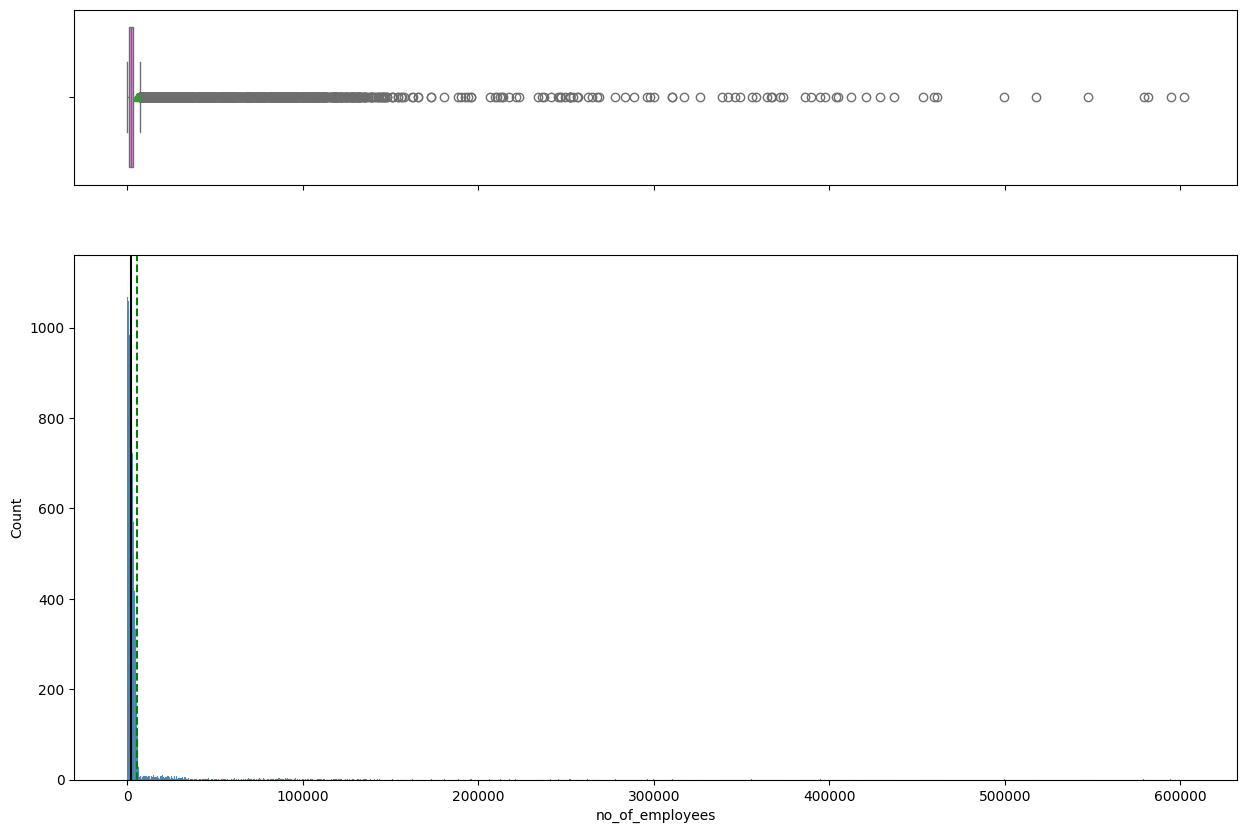

In [ ]:
# View histogram and boxplot for number of employees:
histogram_boxplot(data, 'no_of_employees')

In [ ]:
# Count of rows over 5667 employees:
print("\nThere are", data[data["no_of_employees"] > 5667].shape[0], "number of rows with more than 5667 employees.")

# Count of rows over 300000 employees:
print("\nThere are", data[data["no_of_employees"] > 300000].shape[0], "number of rows with more than 300000 employees.")


There are 1944 number of rows with more than 5667 employees.

There are 35 number of rows with more than 300000 employees.


* The data is extremely right-skewed with many outliers.
* As previously observed in the statistical summary, by and large most applications are for companies is ~5667.
* Only 35 of the applications are for companies with over 300,000 employees.

#####Prevailing Wage

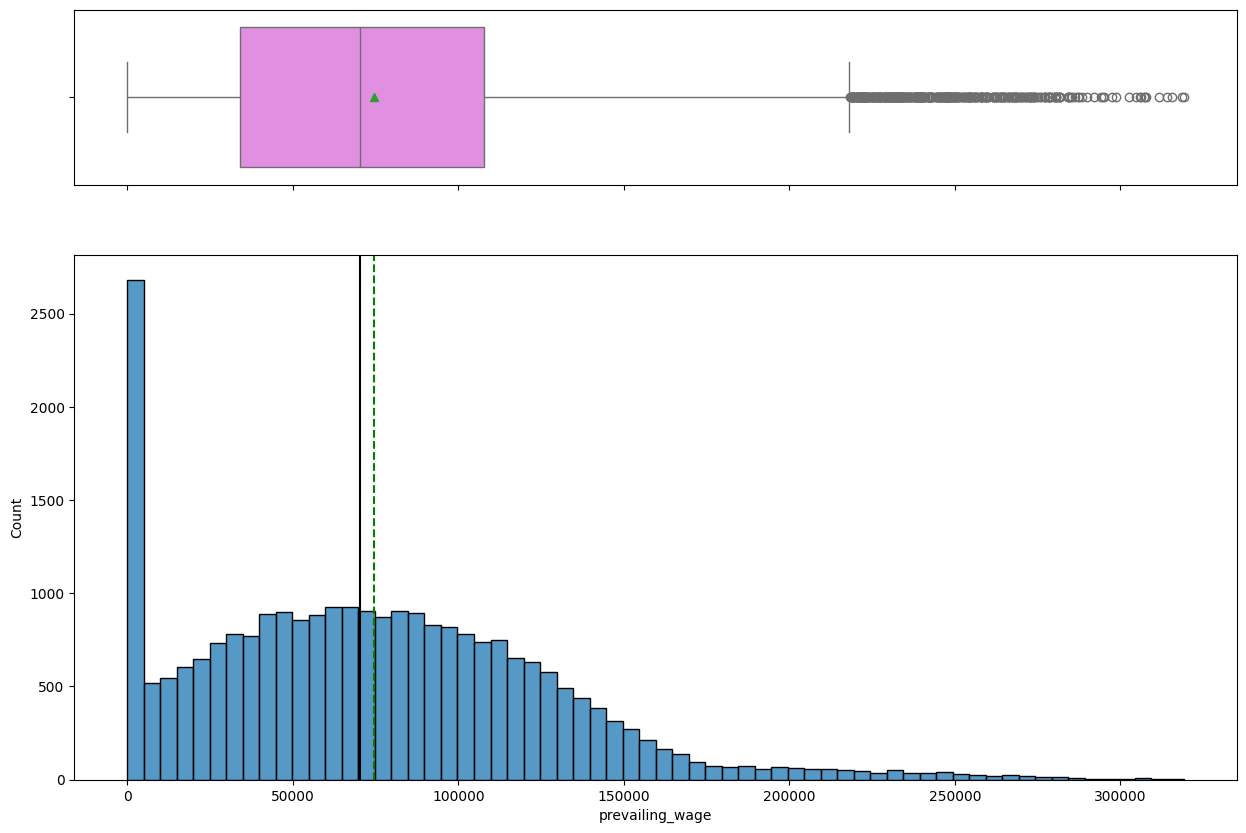

In [ ]:
# View histogram and boxplot for prevailing wage:
histogram_boxplot(data, 'prevailing_wage')

In [ ]:
# Number of records under $100 prevailing wage:
print("\nThere are", data[data["prevailing_wage"] < 100].shape[0], "number of rows with less than $100 prevailing wage.")

# Number of records under $10 prevailing wage:
print("\nThere are", data[data["prevailing_wage"] < 10].shape[0], "number of rows with less than $10 prevailing wage.")


There are 176 number of rows with less than $100 prevailing wage.

There are 14 number of rows with less than $10 prevailing wage.


* As previously noted, the average wage is ~$74,456
* There are 176 applications with a wage under \$100.  This will need to be investigated further if the unit is less more than hourly.
* There are 14 applications with a wage listed under \$10.  At any unit (hourly, daily etc.), this is low.
* The distribution is right-skewed, with quite a few outliers.

#####Year Company Established

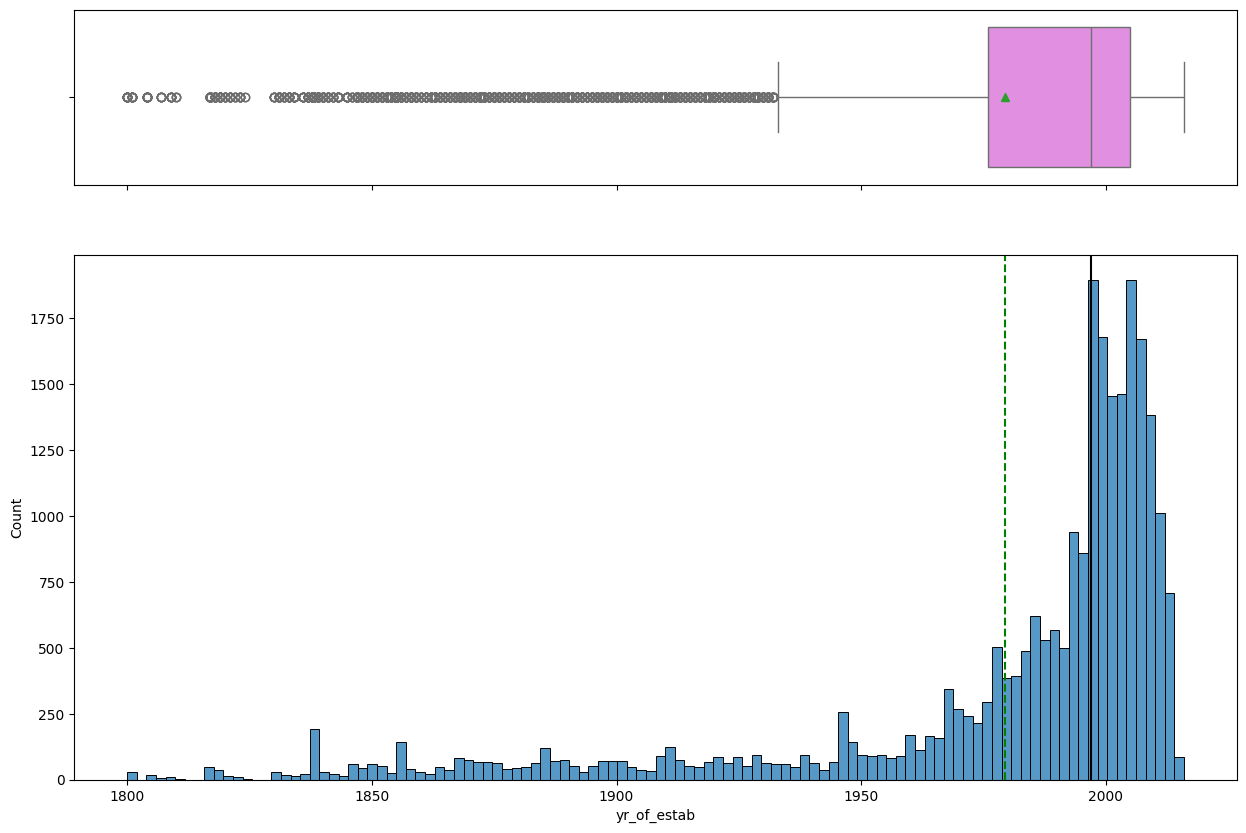

In [ ]:
# View histogram and boxplot for year established:
histogram_boxplot(data, 'yr_of_estab')

* The distribution is very left-skewed with a lot of outliers.
* As previously noted, 75% of the applications are for companies established before 2006.

#####Continent

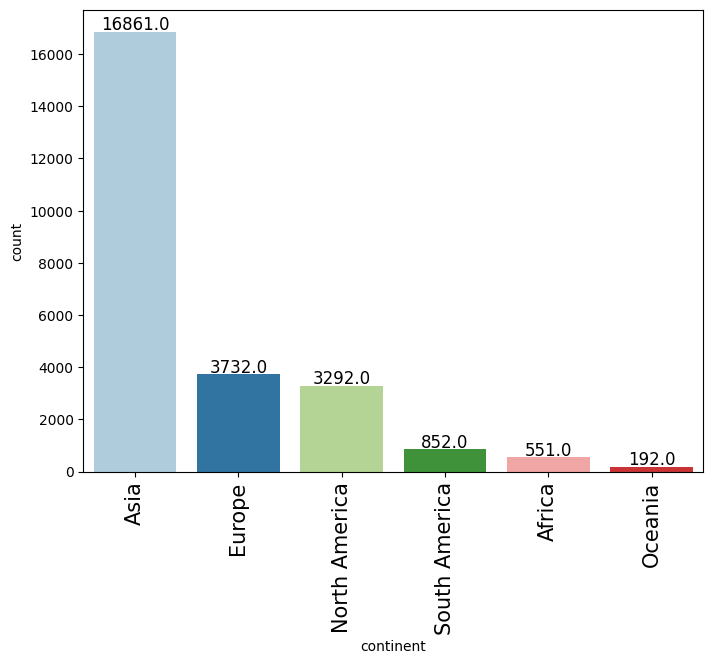

In [ ]:
# labeled barplot for continent:
labeled_barplot(data, 'continent')

* As previously noted, by and large most applications come from Asia, followed by Europe, and then North America for the top three.
* South America and Africa follow, with Oceania having the fewest at 192 applicants.

##### Education Level

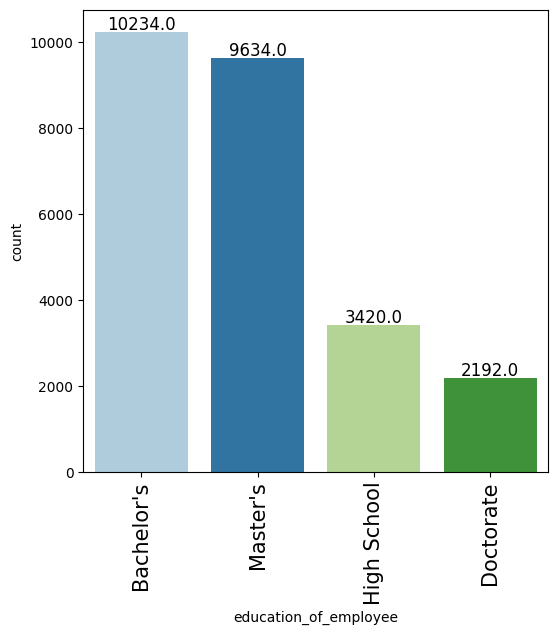

In [ ]:
# labeled barplot for education level:
labeled_barplot(data, 'education_of_employee')

In [ ]:
# Percentages for applications by education level:
data['education_of_employee'].value_counts(normalize=True)

,proportion
education_of_employee,
Bachelor's,0.401648
Master's,0.378100
High School,0.134223
Doctorate,0.086028


* 40% of the applicants have Bachelor's degrees
* 38% have Master's
* 9% have Doctorate's
* 13% do not have higher-education

#####Job Experience

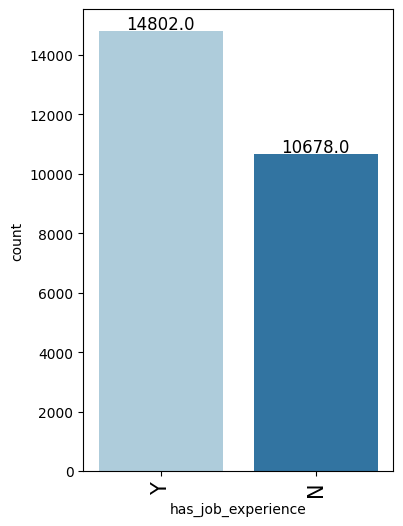

In [ ]:
# labeled barplot for job experience:
labeled_barplot(data, 'has_job_experience')

In [ ]:
# percentages for job experience:
data['has_job_experience'].value_counts(normalize=True)

,proportion
has_job_experience,
Y,0.580926
N,0.419074


* As noted previously, 42% have no job experience.

#####Job Training Required

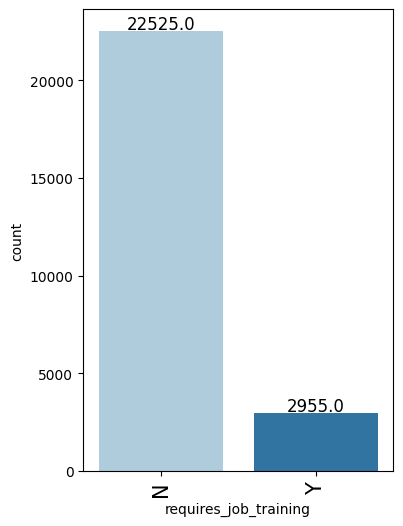

In [ ]:
# labeled barplot for job training:
labeled_barplot(data, 'requires_job_training')

In [ ]:
# Percentages for requires_job_training:
data['requires_job_training'].value_counts(normalize=True)

,proportion
requires_job_training,
N,0.884027
Y,0.115973


* 88% of the applicants do not require job training.

#####Region of Employment

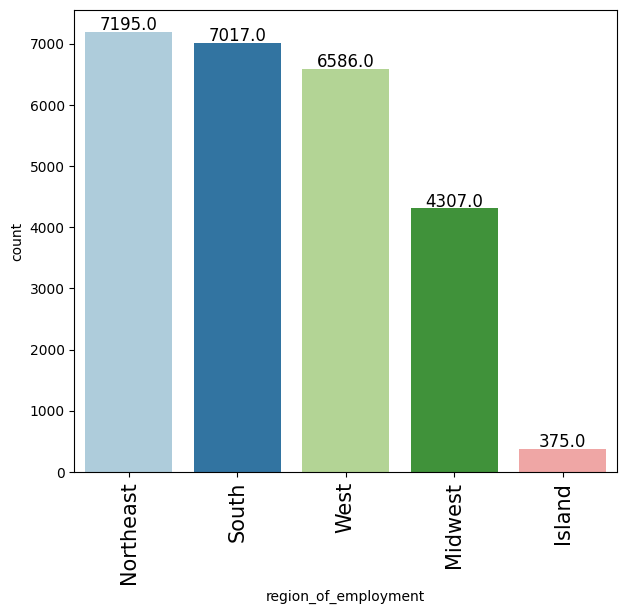

In [ ]:
# labeled barplot for region:
labeled_barplot(data, 'region_of_employment')

* Most applicants are for jobs in the Northeast US, although closely tied with South and West regions.
* The Midwest region trails behind West, with a Island state/territory regions having the fewest at 375 records.

#####Unit of Wage

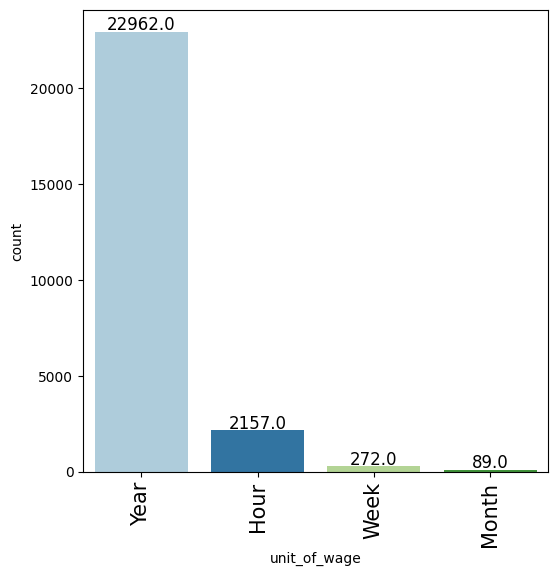

In [ ]:
# labeled bar plot for unit of wage:
labeled_barplot(data, 'unit_of_wage')

In [ ]:
# Percentage for each:
data['unit_of_wage'].value_counts(normalize=True)

,proportion
unit_of_wage,
Year,0.901177
Hour,0.084655
Week,0.010675
Month,0.003493


* 90% of the applications are for an annual wage.
* 8% are for hourly.
* 1% are for weekly
* < 1% are for monthly.

#####Case Status

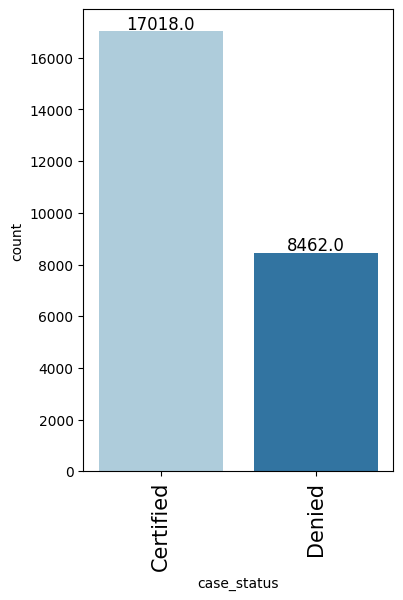

In [ ]:
# labeled barplot for case status:
labeled_barplot(data, 'case_status')

In [ ]:
# percentage for each:
data['case_status'].value_counts(normalize=True)

,proportion
case_status,
Certified,0.667896
Denied,0.332104


* 67% of the applications are certified.

####Bivariate Analysis

##### Set up functions for visualizations

In [ ]:
# Set up distribution plot function:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# Set up stacked bar plot function:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

##### Encode Case_Status (1 for Certified, 0 for Denied)

In [ ]:
# Encode case status for correlation and future analysis:
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)


##### Correlation Matrix (numeric values only)

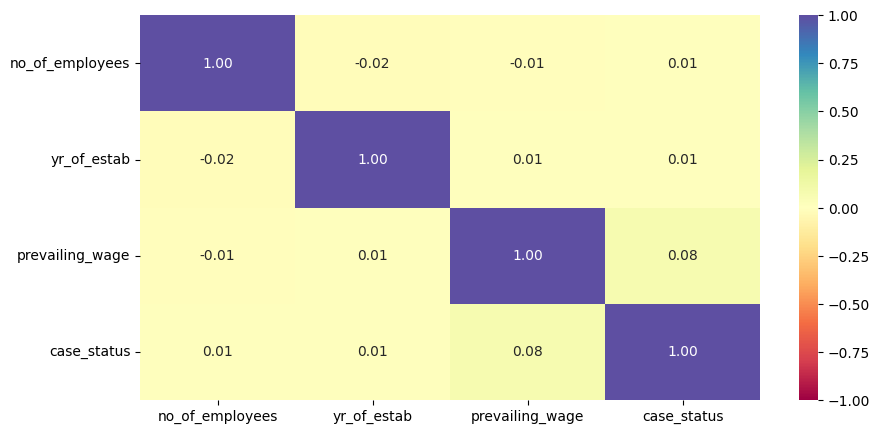

In [ ]:
# Correlation Matrix:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
) ## Complete the code to find the correlation between the variables
plt.show()

* Just looking at the numeric variables with case status, there is no significant correlation.  Prevailing wage has the highest at only .08.

##### Higher Eduction and Case Status

case_status               0      1    All
education_of_employee                    
All                    8462  17018  25480
Bachelor's             3867   6367  10234
High School            2256   1164   3420
Master's               2059   7575   9634
Doctorate               280   1912   2192
------------------------------------------------------------------------------------------------------------------------


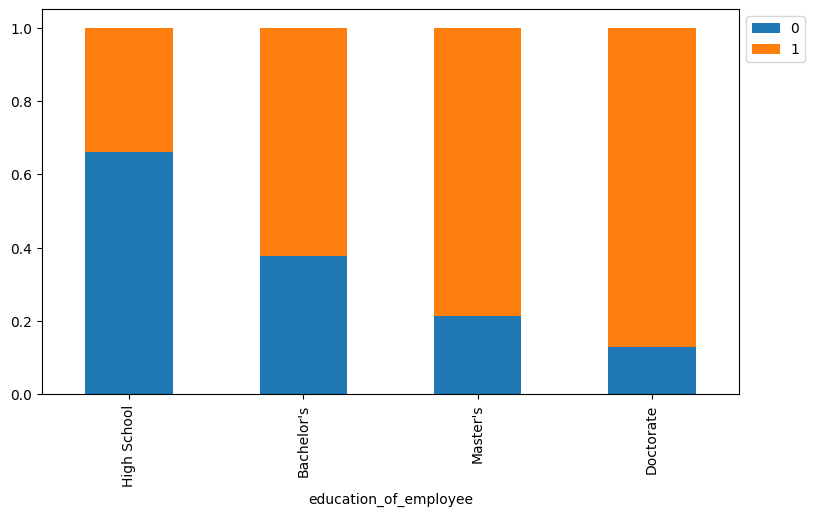

In [ ]:
# Stacked barplot for higher eduction and case status:
stacked_barplot(data, "education_of_employee", "case_status")

In [ ]:
# Percentage of status of certified by education of employee:
data.groupby("education_of_employee")["case_status"].value_counts(normalize=True)

education_of_employee  case_status
Bachelor's             1              0.622142
                       0              0.377858
Doctorate              1              0.872263
                       0              0.127737
High School            0              0.659649
                       1              0.340351
Master's               1              0.786278
                       0              0.213722
Name: proportion, dtype: float64

###### Does education have impact on visa certification?
* The higher the education, the more likely for visas to be approved.
* 87% of those with doctorates are approved.
* 34% of those with only a high school education are approved.

#####Region and Education

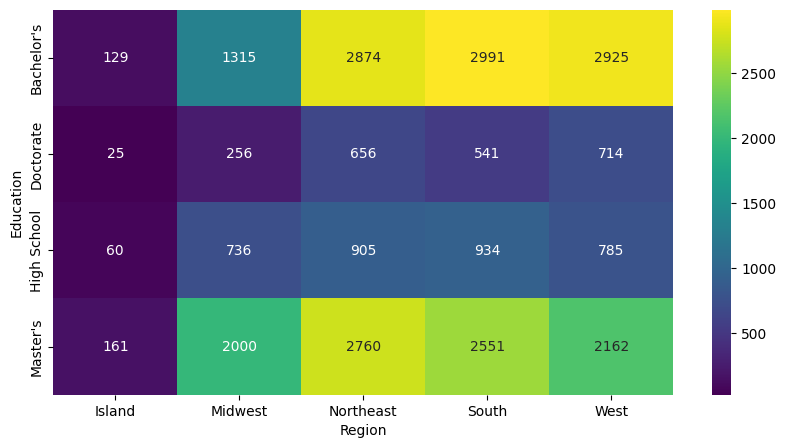

In [ ]:
# Plot heatmap for the crosstab between education and region of employment:
plt.figure(figsize=(10, 5))
sns.heatmap(
    pd.crosstab(data["education_of_employee"], data["region_of_employment"]),
    annot=True,
    fmt="g",
    cmap="viridis"
)
plt.ylabel("Education")
plt.xlabel("Region")
plt.show()

In [ ]:
# Percent of each education level for each region regardless of visa status:
print("Education level percentages of all visa requests by region:\n")
data.groupby("region_of_employment")["education_of_employee"].value_counts(normalize=True)

Education level percentages of all visa requests by region:



region_of_employment  education_of_employee
Island                Master's                 0.429333
                      Bachelor's               0.344000
                      High School              0.160000
                      Doctorate                0.066667
Midwest               Master's                 0.464360
                      Bachelor's               0.305317
                      High School              0.170885
                      Doctorate                0.059438
Northeast             Bachelor's               0.399444
                      Master's                 0.383600
                      High School              0.125782
                      Doctorate                0.091174
South                 Bachelor's               0.426251
                      Master's                 0.363546
                      High School              0.133105
                      Doctorate                0.077098
West                  Bachelor's               0.444124
                      Master's                 0.328272
                      High School              0.119192
                      Doctorate                0.108412
Name: proportion, dtype: float64

In [ ]:
# Percentage of approved visas by region and education level:
print("Education level percentages of all certified visas by region:\n")
data.groupby(["region_of_employment", "education_of_employee"])["case_status"].value_counts(normalize=True)

Education level percentages of all certified visas by region:



region_of_employment  education_of_employee  case_status
Island                Bachelor's             1              0.596899
                                             0              0.403101
                      Doctorate              1              0.880000
                                             0              0.120000
                      High School            0              0.700000
                                             1              0.300000
                      Master's               1              0.677019
                                             0              0.322981
Midwest               Bachelor's             1              0.733080
                                             0              0.266920
                      Doctorate              1              0.906250
                                             0              0.093750
                      High School            0              0.595109
                                             1              0.404891
                      Master's               1              0.879500
                                             0              0.120500
Northeast             Bachelor's             1              0.567502
                                             0              0.432498
                      Doctorate              1              0.864329
                                             0              0.135671
                      High School            0              0.709392
                                             1              0.290608
                      Master's               1              0.748188
                                             0              0.251812
South                 Bachelor's             1              0.662655
                                             0              0.337345
                      Doctorate              1              0.900185
                                             0              0.099815
                      High School            0              0.619914
                                             1              0.380086
                      Master's               1              0.818895
                                             0              0.181105
West                  Bachelor's             1              0.585641
                                             0              0.414359
                      Doctorate              1              0.845938
                                             0              0.154062
                      High School            0              0.707006
                                             1              0.292994
                      Master's               1              0.718316
                                             0              0.281684
Name: proportion, dtype: float64

* Most visa applicants in the South, West, and Northeast regions have only bachelor degrees.
* The next most frequent education level for applications for South, West, and Northeast regions are for those with master's degrees.
* The Midwest and Island regions break that pattern with having more applicants with master's degrees, followed by bachelor's degrees.
* In all regions, high school and doctorate education levels are the least frequent education level for visa applicants, with the West region have the highest percentage (11%) of doctorates.
* Doctorate visa applicants have the highest percentage of certification in any region, with the Midwest and South closely tied at a rate of ~90%.

#####Region and Case Status

case_status              0      1    All
region_of_employment                    
All                   8462  17018  25480
Northeast             2669   4526   7195
West                  2486   4100   6586
South                 2104   4913   7017
Midwest               1054   3253   4307
Island                 149    226    375
------------------------------------------------------------------------------------------------------------------------


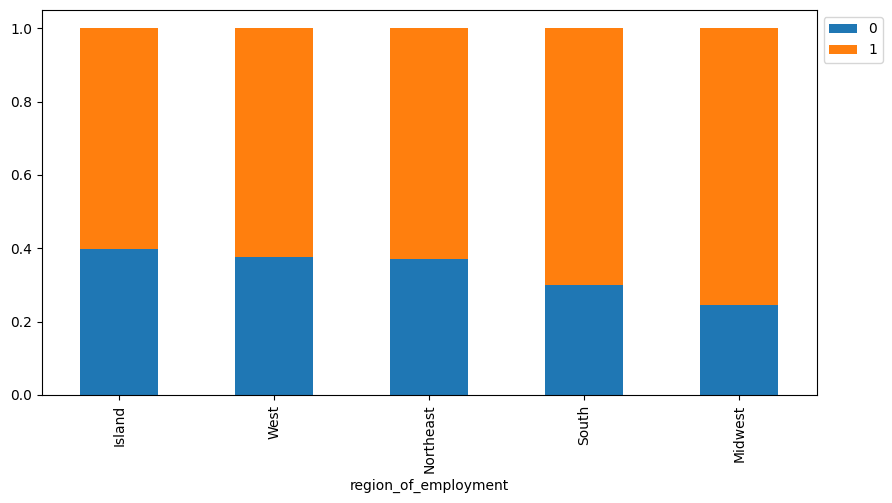

In [ ]:
# Stacked barplot for region of employment and case status:
stacked_barplot(data, "region_of_employment", "case_status")

In [ ]:
# Percentage of certified by region:
data.groupby("region_of_employment")["case_status"].value_counts(normalize=True)

region_of_employment  case_status
Island                1              0.602667
                      0              0.397333
Midwest               1              0.755282
                      0              0.244718
Northeast             1              0.629048
                      0              0.370952
South                 1              0.700157
                      0              0.299843
West                  1              0.622533
                      0              0.377467
Name: proportion, dtype: float64

######What are the percentage of visa certifications by region?
* The highest percentage of certified applicants are for the Midwest region (76%), followed by South (70%).
* The Island, Northeast, and West regions all hover around 60-63% certification.

#####Continent and Case Status

case_status       0      1    All
continent                        
All            8462  17018  25480
Asia           5849  11012  16861
North America  1255   2037   3292
Europe          775   2957   3732
South America   359    493    852
Africa          154    397    551
Oceania          70    122    192
------------------------------------------------------------------------------------------------------------------------


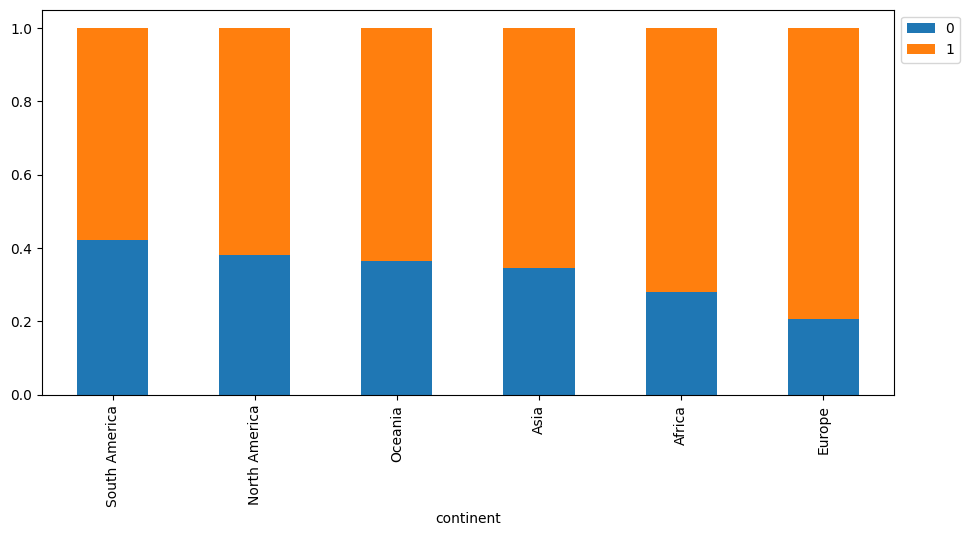

In [ ]:
# Stacked barplot for continent and case status:
stacked_barplot(data, "continent", "case_status")

In [ ]:
# Percentage of certification status and continent:
data.groupby("continent")["case_status"].value_counts(normalize=True)

continent      case_status
Africa         1              0.720508
               0              0.279492
Asia           1              0.653105
               0              0.346895
Europe         1              0.792337
               0              0.207663
North America  1              0.618773
               0              0.381227
Oceania        1              0.635417
               0              0.364583
South America  1              0.578638
               0              0.421362
Name: proportion, dtype: float64

######What are the percentage of visa certifications by continent?
* Europeans have the highest success rate of visa certification at nearly 80%.
* Africans (72%), Asians (65%), Oceanians(64%), and North Americans (62%) follow in visa certification.
* South American have the lowest success rate of visa certification at 58%.

#####Work Experience and Case Status

case_status            0      1    All
has_job_experience                    
All                 8462  17018  25480
N                   4684   5994  10678
Y                   3778  11024  14802
------------------------------------------------------------------------------------------------------------------------


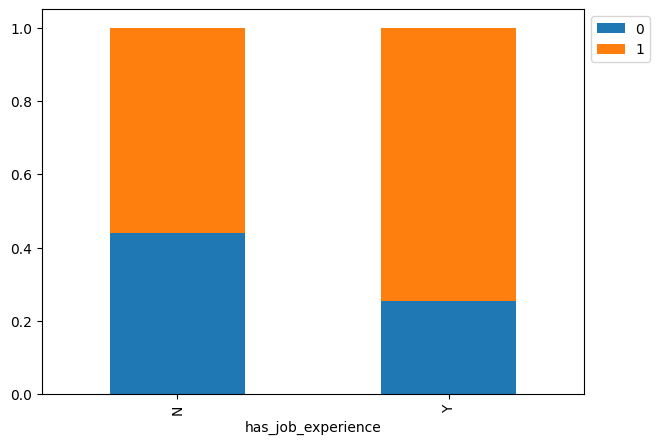

In [ ]:
# Stacked barplot for job experience and case status:
stacked_barplot(data, "has_job_experience", "case_status")

In [ ]:
# Percent of candiates with job experience by case status:
data.groupby("has_job_experience")["case_status"].value_counts(normalize=True)

has_job_experience  case_status
N                   1              0.561341
                    0              0.438659
Y                   1              0.744764
                    0              0.255236
Name: proportion, dtype: float64

######Does having work experience influence visa certification?
* Those with job experience get visa certification at 75%.
* Those without job experience get visa certification at 56%.

#####Work Experience and Job Training

requires_job_training      N     Y    All
has_job_experience                       
All                    22525  2955  25480
N                       8988  1690  10678
Y                      13537  1265  14802
------------------------------------------------------------------------------------------------------------------------


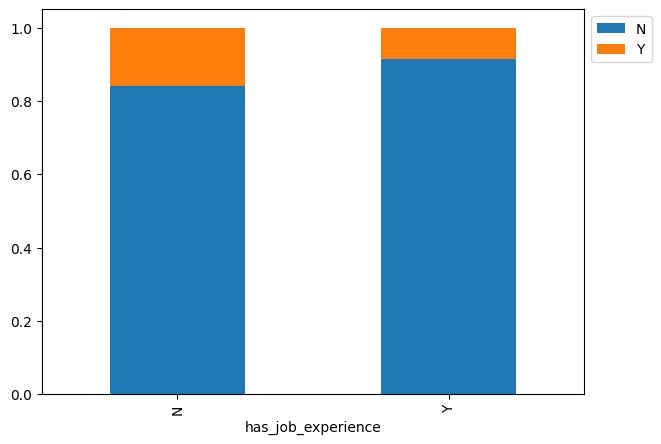

In [ ]:
# Stacked barplot for job experience and requires_job_training:
stacked_barplot(data, "has_job_experience", "requires_job_training")

In [ ]:
# Percentage of on the job training by work experience:
data.groupby("has_job_experience")["requires_job_training"].value_counts(normalize=True)

has_job_experience  requires_job_training
N                   N                        0.841731
                    Y                        0.158269
Y                   N                        0.914539
                    Y                        0.085461
Name: proportion, dtype: float64

In [ ]:
# Percentage of approved visas requiring on the job training by work experience:
data.groupby(["has_job_experience", "requires_job_training"])["case_status"].value_counts(normalize=True)

has_job_experience  requires_job_training  case_status
N                   N                      1              0.548732
                                           0              0.451268
                    Y                      1              0.628402
                                           0              0.371598
Y                   N                      1              0.744626
                                           0              0.255374
                    Y                      1              0.746245
                                           0              0.253755
Name: proportion, dtype: float64

######Do employees who have prior work experience require job training?
* Most applicants do not require job training, despite their prior work experience.
* 16% of those without work experience require on the job training.
* 9% of those with work experience require on the job training.
* Visa applicants with prior experience, regardless if the job requires it or not get certified at ~75%.
* Visa applicants *without* prior experience when *training is required* get certified at ~63%, as opposed to jobs *not requiring training* at ~55%.

##### Prevailing Wage and Case Status

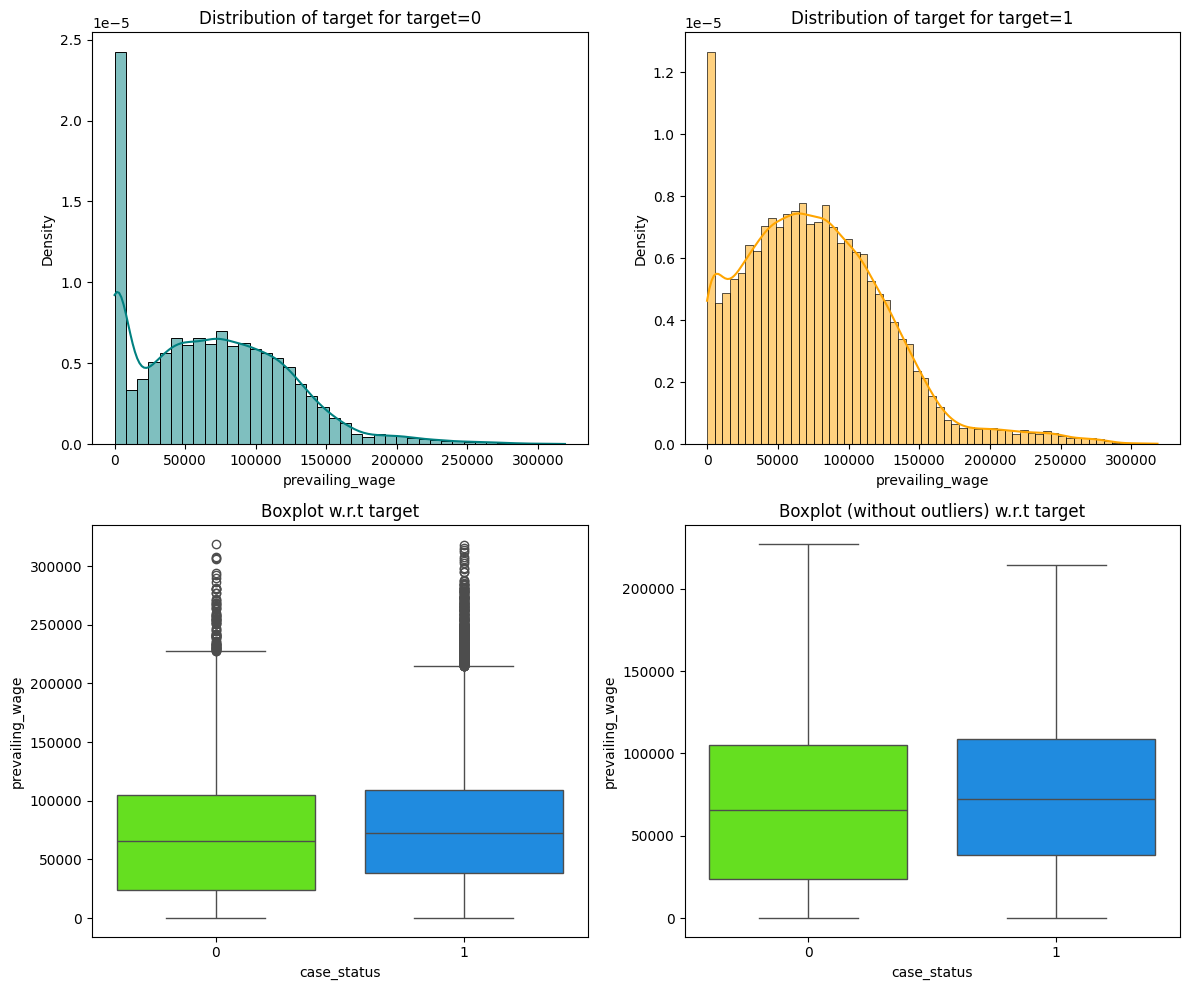

In [ ]:
# Plot distribution of prevailing wage and case status:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

In [ ]:
# Median prevailing wage by case status:
data.groupby("case_status")["prevailing_wage"].median()

,prevailing_wage
case_status,
0,65431.46
1,72486.27


In [ ]:
# Prevailing wage and unit by status:
data.groupby(["case_status", "unit_of_wage"])["prevailing_wage"].median()[1]

,prevailing_wage
unit_of_wage,
Hour,376.6703
Month,81826.0100
Week,85297.7800
Year,75427.8400


In [ ]:
# See median prevailing wage for case status=1, by education level, unit of wage
data[data["case_status"] == 1].groupby(["education_of_employee", "unit_of_wage"])["prevailing_wage"].median()

education_of_employee  unit_of_wage
Bachelor's             Hour              358.87720
                       Month           92220.06500
                       Week            84214.30000
                       Year            76005.09000
Doctorate              Hour              362.82935
                       Month           39778.73000
                       Week            82663.23500
                       Year            60008.40500
High School            Hour              433.72685
                       Month           46045.67500
                       Week            84860.64500
                       Year            73752.54000
Master's               Hour              404.78620
                       Month           82793.80000
                       Week            87483.78500
                       Year            78960.04000
Name: prevailing_wage, dtype: float64

######Does visa status change with prevailing wage?
* Based on this data, the median wage for certified applicants is $72,486:
  *  \$377 if hourly
  *  \$85,298 if weekly
  *  \$81,826 if monthly
  *  \$75,428 if yearly
  
* The median wage for denied applications is \$65,431.

* Overall, the prevailing wage data does not appear to scale with expectations at any unit:
  * Those with a doctorates consistently make often significantly less than any other education level.
  * Those with only a high-school education up to $75 more that applicants with higher education.
* Without knowing more about the actual job and qualifications, it's difficult to assess if the wages are protective.

#####Prevailing Wage and Region

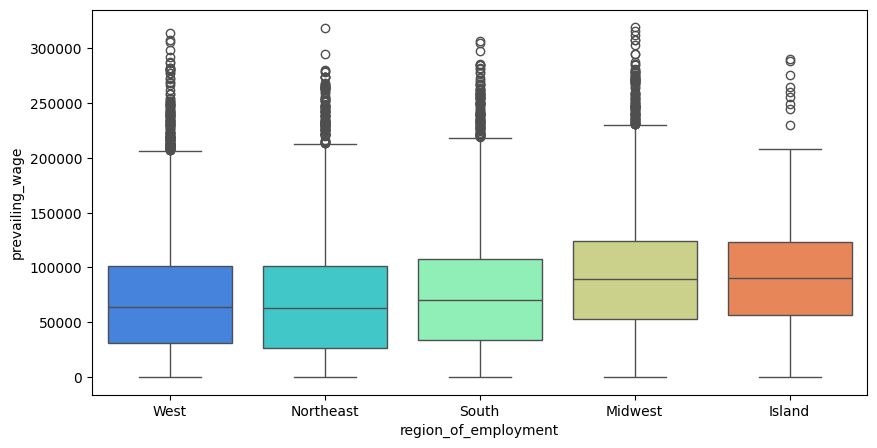

In [ ]:
# Boxplot for region of employment and prevailing wage:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="region_of_employment", y="prevailing_wage", palette="rainbow")
plt.show()

In [ ]:
# Median prevailing wage by region:
data.groupby("region_of_employment")["prevailing_wage"].median()

,prevailing_wage
region_of_employment,
Island,90678.17
Midwest,89153.91
Northeast,63276.51
South,70191.52
West,64358.44


######Is the prevailing wage similar across all the US regions?
* Island jobs for applicants have the highest prevailing wage at ~$90k with Midwest jobs a close second at ~\$89k.
* South jobs for applicants fall around \$70k.
* West jobs have a prevailing wage of ~\$64k, followed closely by Northeast at ~\$63k.

#####Wage Unit and Case Status

case_status      0      1    All
unit_of_wage                    
All           8462  17018  25480
Year          6915  16047  22962
Hour          1410    747   2157
Week           103    169    272
Month           34     55     89
------------------------------------------------------------------------------------------------------------------------


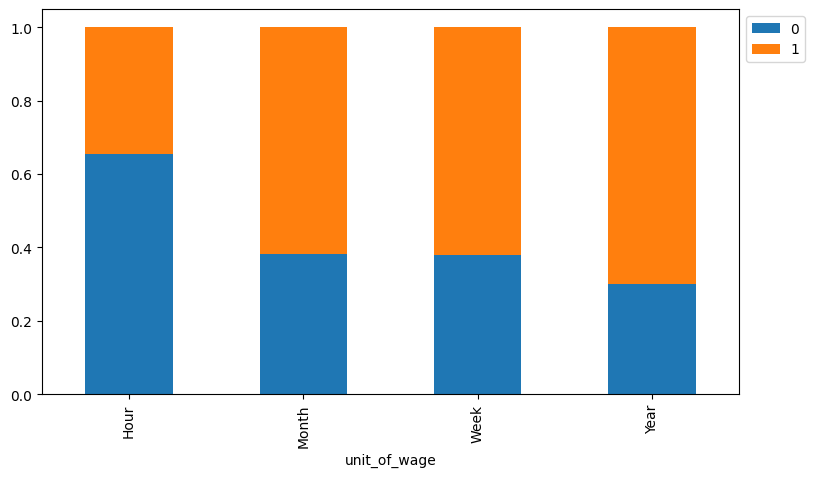

In [ ]:
# Stacked barplot for unit of wage and case status:
stacked_barplot(data, "unit_of_wage", "case_status")

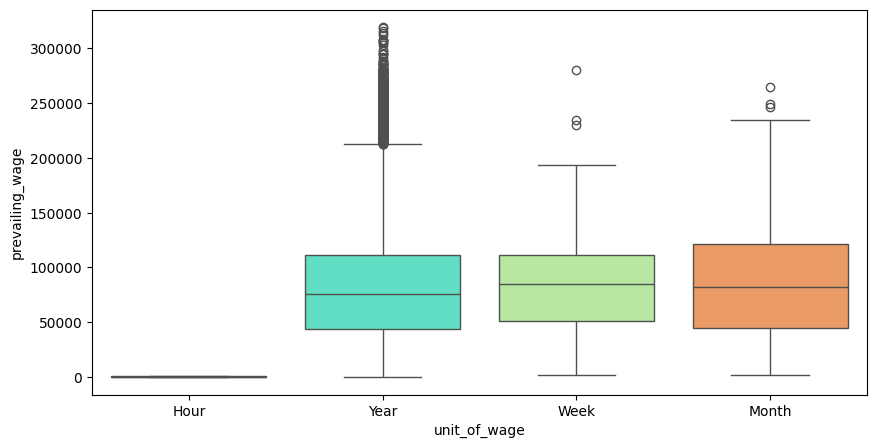

In [ ]:
# Plot Median Wage by Year:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="unit_of_wage", y="prevailing_wage", palette="rainbow")
plt.show()

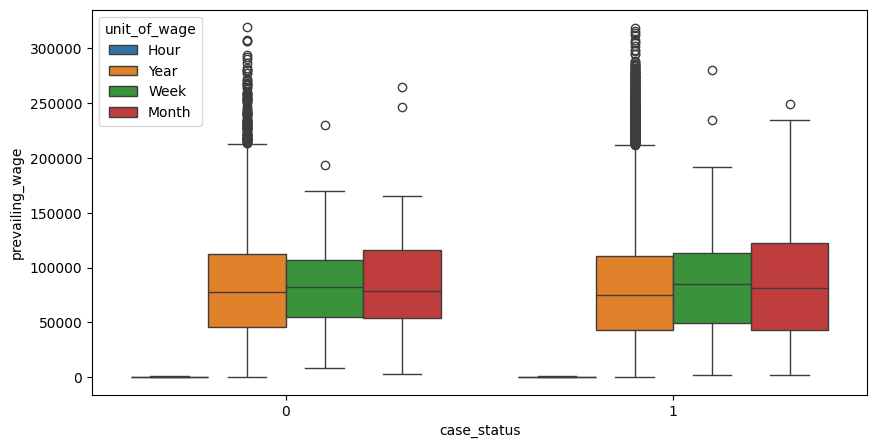

In [ ]:
# Graph annual wage and wage unit by case status:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="case_status", y="prevailing_wage", hue="unit_of_wage")
plt.show()

In [ ]:
# Percentage of approvals by wage unit:
data.groupby("unit_of_wage")["case_status"].value_counts(normalize=True)

unit_of_wage  case_status
Hour          0              0.653686
              1              0.346314
Month         1              0.617978
              0              0.382022
Week          1              0.621324
              0              0.378676
Year          1              0.698850
              0              0.301150
Name: proportion, dtype: float64

In [ ]:
# Median prevailing wage by unit and case status:
data.groupby(["unit_of_wage", "case_status"])["prevailing_wage"].median()

unit_of_wage  case_status
Hour          0                367.79305
              1                376.67030
Month         0              78924.03500
              1              81826.01000
Week          0              82042.03000
              1              85297.78000
Year          0              77697.21000
              1              75427.84000
Name: prevailing_wage, dtype: float64

In [ ]:
# Median prevailing wage by unit:
data.groupby("unit_of_wage")["prevailing_wage"].median()

,prevailing_wage
unit_of_wage,
Hour,372.6523
Month,81826.0100
Week,85075.8200
Year,76174.5000


In [ ]:
# Average prevailing wage by unit:
data.groupby("unit_of_wage")["prevailing_wage"].mean()

,prevailing_wage
unit_of_wage,
Hour,414.570513
Month,87592.864045
Week,85606.820515
Year,81228.077133


######Does the unit of wage impact visa certifications?
* Annual wage unit applications have the most outliers, and are approved 70% of the time.
* Monthly and weekly wage unit applications are approved only 62% of the time.
* Curiously, with or without outliers averaged in, the wage falls within less than a \$10k difference amongst annual, monthly or weekly units, which is extremely counterintuitive.
* The hourly rate of ~$376 also seems unrealisitic for full-time, but may be higher due to the positions being part-time.
* For hourly, weekly, and monthly units, the applications approved have higher wages than their denied counterparts.
* The normalized annual salary of ~\$75k for certified applicants is just a little over \$2k less than the annual salary for denied applicants.

## Data Preprocessing

- Missing value treatment (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling

####Missing Value Check

In [ ]:
# Missing values?
data.isnull().sum()

,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0
full_time_position,0


* No missing values, as also seen when reviewing categorical value counts.

###Outlier Check

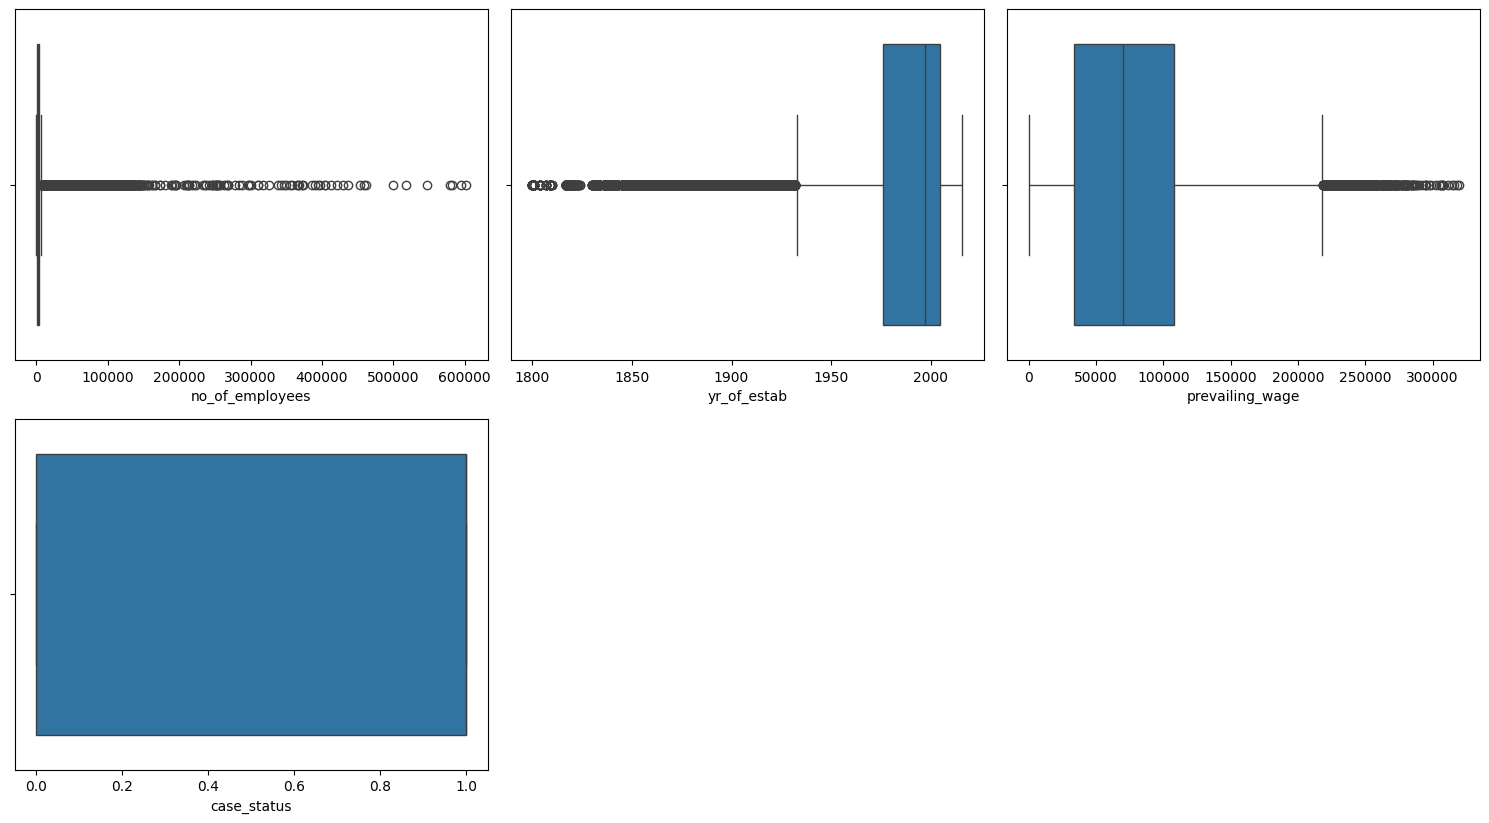

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=data, x=variable)
    plt.tight_layout()
plt.show()

In [ ]:
# Lowest number of employees for any record:
data["no_of_employees"].min()

11

In [ ]:
# For companies established prior to 1900, find minimum employee count:
data[data["yr_of_estab"] < 1900]["no_of_employees"].min()
# What is the count of records for this category?


18

In [ ]:
# Show all records with 18 employees:
data[data["no_of_employees"] == 18]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
28,Asia,Master's,Y,N,18,2004,Northeast,40925.8600,Year,Y,1
4379,Asia,Master's,Y,N,18,2000,Midwest,15064.8300,Year,Y,1
7653,Asia,Bachelor's,Y,N,18,2000,Northeast,110859.6000,Year,Y,0
8598,Asia,Bachelor's,N,N,18,1996,South,95222.2700,Year,Y,1
9897,Asia,High School,Y,N,18,2001,West,272311.2100,Year,Y,0
10867,South America,Bachelor's,N,N,18,2010,South,125539.1500,Year,Y,0
13526,Asia,Bachelor's,N,N,18,2011,South,349.9129,Hour,Y,0
16119,Europe,Bachelor's,Y,N,18,1993,West,23609.8400,Year,Y,1
21979,Asia,Doctorate,Y,Y,18,1950,South,65932.5400,Year,Y,1
25367,Europe,High School,N,Y,18,1831,South,125704.6800,Year,Y,1


**No outlier treatment required:**
* There are significant outliers for number of employees, however the minimum of 11 for any company and 18 for any company established prior to 1900 is plausible.
* The year established are all actual values.
* There is not enough evidence to contest or treat the wage values as anything but actual, given no information was provided about industry, or job requirements for education, skills, or experience.  

###Data Preparation for Modeling

- Predict which visas will be certified.
- Split the data into train and test to prepare for model building.

In [ ]:
# Drop the target variable case_status from the data:
X = data.drop("case_status", axis=1)
Y = data["case_status"]

# Create dummies for X:
X = pd.get_dummies(X, drop_first=True)

# Splitting data in train and test sets with a 70:30 ration:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1, stratify=Y)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of test set :  (7644, 21)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64


## Model Building

###Model Evaluation Criterion

Model can make wrong predictions as:

* Model predicts that the visa application will get certified but in reality, the visa application should get denied.
* Model predicts that the visa application will not get certified but in reality, the visa application should get certified.

Which case is more important?

**Both** the cases are important as:

* If a visa is certified when it had to be denied a wrong employee will get the job position while US citizens will miss the opportunity to work on that position.

* If a visa is denied when it had to be certified the U.S. will lose a suitable human resource that can contribute to the economy.

How to reduce the losses?

* **F1 Score** can be used a the metric for evaluation of the model, greater the F1 score higher are the chances of minimizing False Negatives and False Positives.

* We will use **balanced class weights** so that models focus equally on both classes.

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.

* The model_performance_classification_sklearn function will be used to check the model performance of models.
* The confusion_matrix_sklearn function will be used to plot the confusion matrix.

###**Note:  Provided Hyperparameters**

Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```

### Define model matrix and performance functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Decision Tree - Model Building and Hyperparameter Tuning

#### Build Decision Tree Model

In [ ]:
# Define decision tree classifier with balanced weights and random state = 1:
dt_model = DecisionTreeClassifier(class_weight="balanced", random_state=1)

# Fit the model on the train data:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

#####Check Decision Tree performance on train

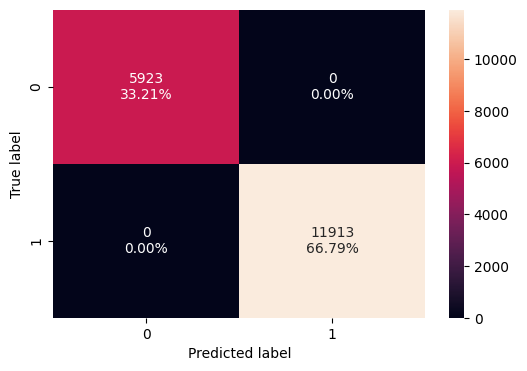

In [ ]:
# Create confusion matrix for train data:
confusion_matrix_sklearn(dt_model, X_train, y_train)

In [ ]:
# Check performance on train data:
decision_tree_perf_train = model_performance_classification_sklearn(dt_model, X_train, y_train)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


* On the train data, the true positives are 33.21% and true negatives are 66.79%.
* As expected, the model at this point will overfit to the train data with perfect 1 scores across accuracy, recall, precision and F1.

#####Check Decision Tree performance on test

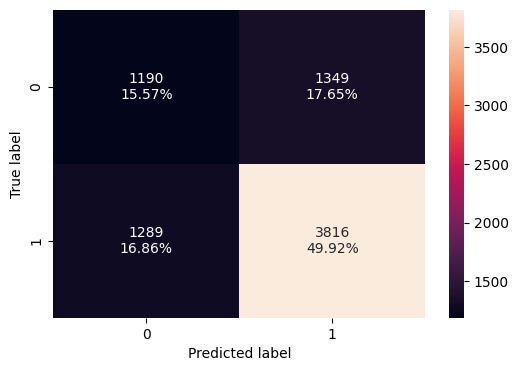

In [ ]:
# Create confusion matrix for test data:
confusion_matrix_sklearn(dt_model, X_test, y_test)

In [ ]:
# Check performance on test data:
decision_tree_perf_test = model_performance_classification_sklearn(dt_model, X_test, y_test)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.654893,0.747502,0.738819,0.743135


* As expected, the true positives and negatives are respectively lower than on test, with false negatives and false positives introduced.
* The F1 score is .743 on test with this initial decision tree model.

####Hyperparameter Tuning - Decision Tree

In [ ]:
# Choose the type of classifier.
dtree_estimator = DecisionTreeClassifier(class_weight="balanced", random_state=1)

# Grid of parameters to choose from
parameters = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search with n_jobs = -1
grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer, cv=5, n_jobs=-1)

# Fit the grid_obj on the train data:
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dtree_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dtree_estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, max_leaf_nodes=10,
                       min_impurity_decrease=0.0001, random_state=1)

#####Check tuned Decision Tree performance on train

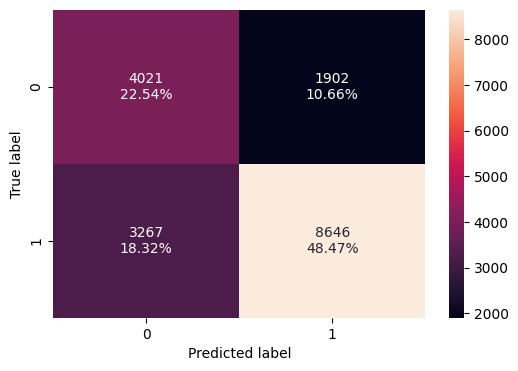

In [ ]:
# Confusion matrix on tuned dtree on train:
confusion_matrix_sklearn(dtree_estimator, X_train,y_train)

In [ ]:
# Get performance metrics on tuned dtree on train:
dtree_estimator_model_train_perf=model_performance_classification_sklearn(dtree_estimator, X_train,y_train)
print("Training performance: \n",dtree_estimator_model_train_perf)

Training performance: 
    Accuracy    Recall  Precision        F1
0  0.710193  0.725762   0.819681  0.769868


* The tuned decision tree model is a lot less overfit now with a F1 score of .770 on train.

#####Check tuned Decision Tree performance on test

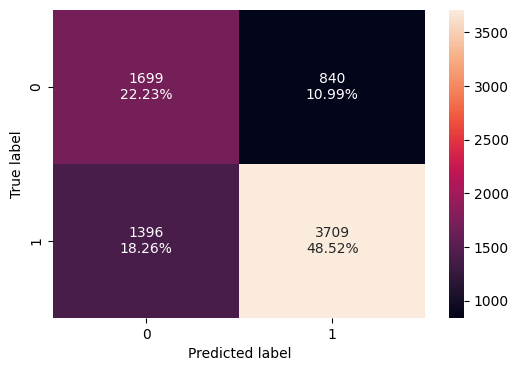

In [ ]:
# Confusion matrix on tuned dtree on test:
confusion_matrix_sklearn(dtree_estimator, X_test,y_test)

In [ ]:
# Performance metrics on tuned dtree on test:
dtree_estimator_model_test_perf=model_performance_classification_sklearn(dtree_estimator, X_test,y_test)
print("Testing performance: \n",dtree_estimator_model_test_perf)

Testing performance: 
    Accuracy    Recall  Precision        F1
0  0.707483  0.726543   0.815344  0.768386


* The F1 score on the tuned decision tree went up to .768 (from .743) on test.
* More importantly, the tuned decision tree model has much more consistent scores across the board between train and test.
* Below .80 is still not fabulous.  Let's see what other models yield.

### Bagging - Model Building and Hyperparameter Tuning

#### Build Bagging Classifier

In [ ]:
# Define bagging classifier with random state = 1:
bagging_classifier = BaggingClassifier(random_state=1)

# Fit bagging classifier on the train data
bagging_classifier.fit(X_train, y_train)

BaggingClassifier(random_state=1)

##### Check Bagging performance on train:

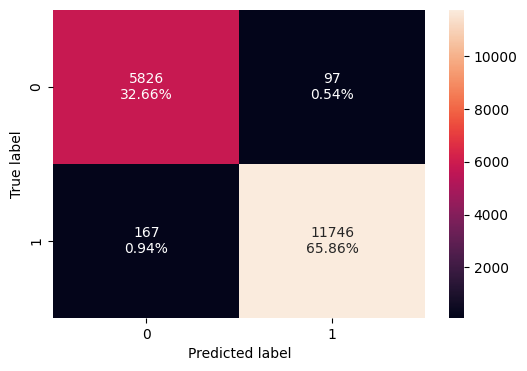

In [ ]:
# Confusion matrix on bagging classifier on train:
confusion_matrix_sklearn(bagging_classifier, X_train,y_train)

In [ ]:
# Performance metrics on bagging classifier on train:
bagging_classifier_model_train_perf=model_performance_classification_sklearn(bagging_classifier, X_train,y_train)
print("Training performance: \n",bagging_classifier_model_train_perf)

Training performance: 
    Accuracy    Recall  Precision        F1
0  0.985198  0.985982    0.99181  0.988887


* The default bagging model is likely overfitting on train with a .989 F1 score.
* Before tuning the True Positive rate is 65.86% and the True Negative rate is 32.66%.

##### Check Bagging performance on test:

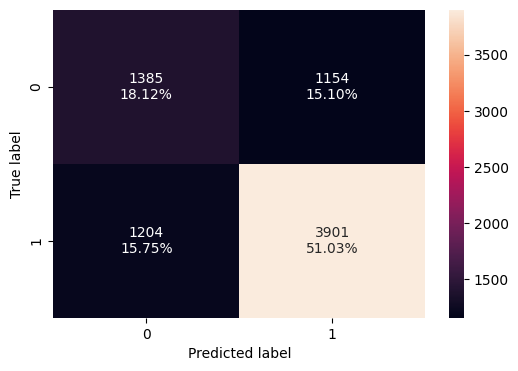

In [ ]:
# Confusion matrix on bagging classifier on test:
confusion_matrix_sklearn(bagging_classifier, X_test,y_test)

In [ ]:
# Performance metrics on bagging classifier on test:
bagging_classifier_model_test_perf=model_performance_classification_sklearn(bagging_classifier, X_test,y_test)
print("Testing performance: \n",bagging_classifier_model_test_perf)

Testing performance: 
    Accuracy    Recall  Precision        F1
0  0.691523  0.764153   0.771711  0.767913


* The default bagging model is definitely overfitting on train, as the F1 score dropped to .768 on test data.
* Before tuning the True Positive rate is 51.03% and the True Negative rate is 18.12%.

####Hyperparameter Tuning - Bagging

In [ ]:
# Choose the type of classifier.
bagging_estimator_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search with cv = 5
grid_obj = GridSearchCV(BaggingClassifier(random_state=1,bootstrap=True), param_grid=parameters, scoring=acc_scorer, cv = 5)

# Fit the grid_obj on train data
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

BaggingClassifier(max_features=0.7, max_samples=0.8, n_estimators=70,
                  random_state=1)

##### Check tuned Bagging on train

Confusion matrix for tuned bagging estimator on train:



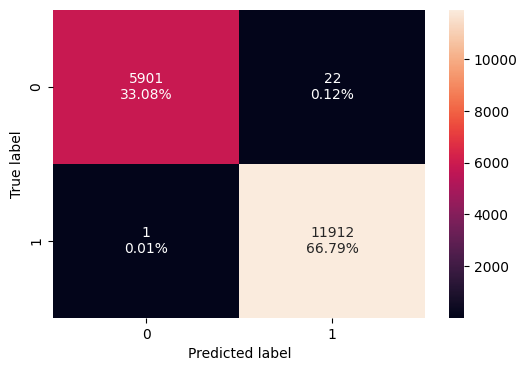

In [ ]:
# Confusion matrix on tuned bagging model on train:
print("Confusion matrix for tuned bagging estimator on train:\n")
confusion_matrix_sklearn(bagging_estimator_tuned, X_train, y_train)

In [ ]:
# Performance metrics on tuned bagging model on train:
bagging_estimator_tuned_model_train_perf=model_performance_classification_sklearn(bagging_estimator_tuned,X_train,y_train)
print("Training performance:\n",bagging_estimator_tuned_model_train_perf)

Training performance:
    Accuracy    Recall  Precision        F1
0   0.99871  0.999916   0.998157  0.999036


* The TP, TN, and F1 scores have not shifted much on the tuned bagging model on train (from the default bagging model).

##### Check tuned Bagging on test

Confusion matrix on tuned bagging model on testing data:



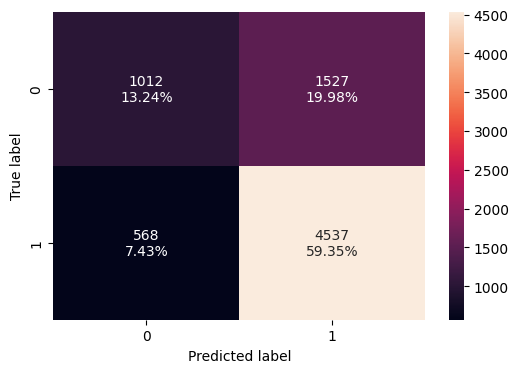

In [ ]:
# Confusion matrix on tuned bagging model on test:
print("Confusion matrix on tuned bagging model on testing data:\n")
confusion_matrix_sklearn(bagging_estimator_tuned, X_test, y_test)

In [ ]:
bagging_estimator_tuned_model_test_perf=model_performance_classification_sklearn(bagging_estimator_tuned,X_test,y_test)
print("Testing performance:\n",bagging_estimator_tuned_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.725929  0.888737   0.748186  0.812427


* The tuned bagging model improved the F1 score on test to .812 (from .768).
* TP moved up to 59.35% (from 51.03%) while TN moved down to 13.24% (from 18.12%).
* The F1 score on the tuned bagging model is higher than on the tuned decision tree model, but it could still be better.

### Random Forest -- Model Building and Hyperparameter Tuning

#### Build Random Forest

In [ ]:
# Define random forest with random state = 1 and class_weight = balanced:
rf_estimator = RandomForestClassifier(random_state=1, class_weight="balanced")

# Fit random forest on the train data:
rf_estimator.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=1)

##### Check Random Forest performance on train

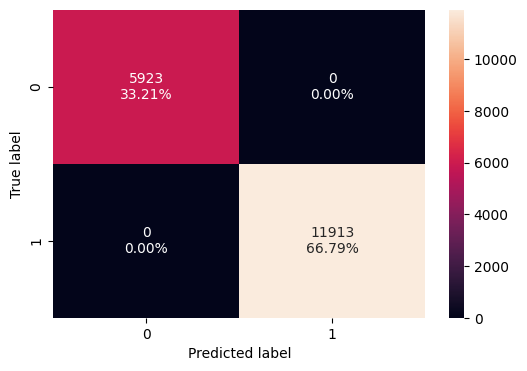

In [ ]:
# Confusion matrix on random forest model on train:
confusion_matrix_sklearn(rf_estimator, X_train,y_train)

In [ ]:
# Performance metrics on random forest model on train:
rf_estimator_model_train_perf = model_performance_classification_sklearn(rf_estimator, X_train,y_train)
print("Training performance", rf_estimator_model_train_perf)

Training performance    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


* As the default estimator for random forest is decision tree, it is expected that all the performance scores will be perfect 1s on train.
* TN is 33.21% and TP is 66.79%.

##### Check Random Forest performance on test

Confusion matrix on random forest model on test:



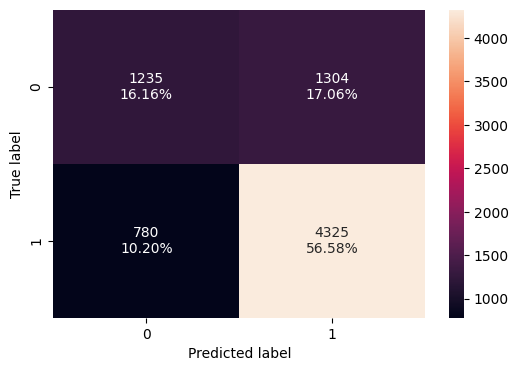

In [ ]:
# Confusion matrix on random forest model on test:
print("Confusion matrix on random forest model on test:\n")
confusion_matrix_sklearn(rf_estimator, X_test,y_test)

In [ ]:
# Performance metrics on random forest model on test:
rf_estimator_model_test_perf = model_performance_classification_sklearn(rf_estimator, X_test,y_test)
print("Testing performance\n", rf_estimator_model_test_perf)

Testing performance
    Accuracy    Recall  Precision        F1
0  0.727368  0.847209   0.768343  0.805851


* F1 score on the default random forest model is .806 on test.
* TP is 56.58% and TN is 16.16%.

#### Hyperparameter Tuning - Random Forest

In [ ]:
# Choose the type of classifier.
rf_tuned = RandomForestClassifier(random_state=1, class_weight="balanced", oob_score=True, bootstrap=True)

parameters = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search with cv = 5 and n_jobs = -1:
grid_obj = GridSearchCV(rf_tuned, param_grid=parameters, scoring=acc_scorer, cv=5, n_jobs=-1)

# Fit the grid_obj on the train data:
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_samples=0.4,
                       n_estimators=110, oob_score=True, random_state=1)

##### Check tuned Random Forest on train

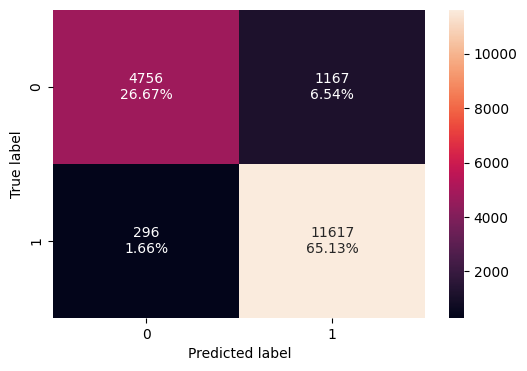

In [ ]:
# Confusion matrix for tuned rf on train:
confusion_matrix_sklearn(rf_tuned, X_train,y_train)

In [ ]:
# Performance metrics of tuned rf on train:
rf_tuned_model_train_perf = model_performance_classification_sklearn(rf_tuned, X_train,y_train)
print("Training performance:\n", rf_tuned_model_train_perf)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.917975  0.975153   0.908714  0.940762


* The F1 score for the tuned random forest model on train is .941, with TP at 65.13% and TN at 26.67%.
* Let's see about test...

##### Check tuned Random Forest on test

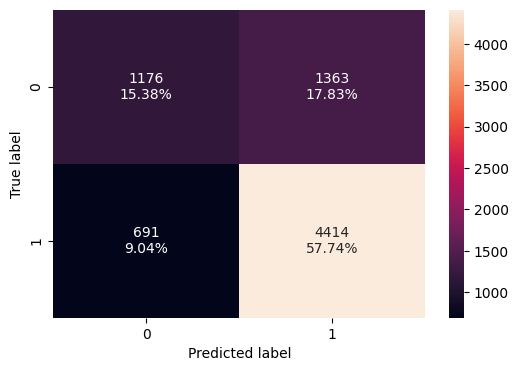

In [ ]:
# Confusion matrix for tuned rf on test:
confusion_matrix_sklearn(rf_tuned, X_test,y_test)

In [ ]:
# Performance metrics of tuned rf on test:
rf_tuned_model_test_perf = model_performance_classification_sklearn(rf_tuned, X_test,y_test)
print("Testing performance:\n", rf_tuned_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.731293  0.864643   0.764064  0.811248


* The tuned random forest model on test increased very slightly to .811 (from .806).
* The confusion matrix and performance scores differ considerably between train and test with the tuned random forest model.  

### Boosting - Model Building and Hyperparameter Tuning

#### Build AdaBoost Classifier

In [ ]:
# Define AdaBoost Classifier with random state = 1:
ab_classifier = AdaBoostClassifier(random_state=1)

# Fit AdaBoost Classifier on the train data:
ab_classifier.fit(X_train, y_train)

AdaBoostClassifier(random_state=1)

#####Check performance of AdaBoost on train

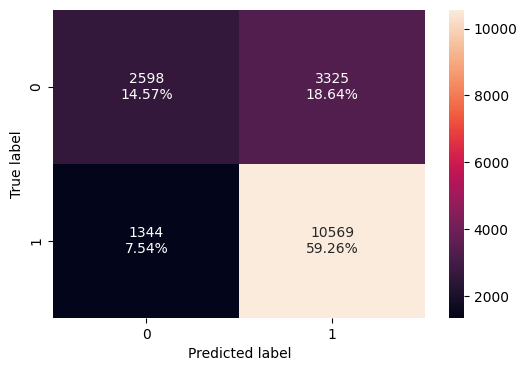

In [ ]:
# Confusion matrix on ab for train data:
confusion_matrix_sklearn(ab_classifier, X_train, y_train)

In [ ]:
# Performance metrics on ab for train:
ab_classifier_model_train_perf = model_performance_classification_sklearn(ab_classifier, X_train, y_train)
print("Training performance:\n", ab_classifier_model_train_perf)

Training performance:
    Accuracy    Recall  Precision       F1
0  0.738226  0.887182   0.760688  0.81908


* The default AdaBoost model has an F1 score of .819 on train.
* The TP is 59.26% and TN is 14.57%.

##### Check performance of AdaBoost on test

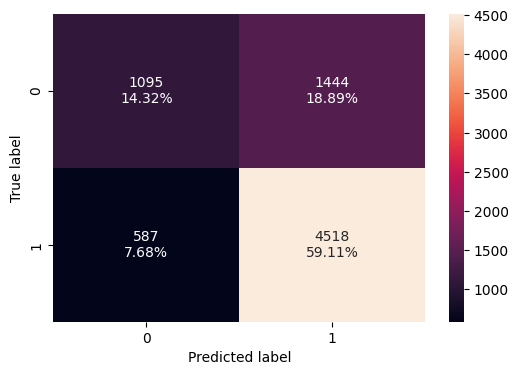

In [ ]:
# Confusion matrix of ab for test data:
confusion_matrix_sklearn(ab_classifier, X_test, y_test)

In [ ]:
# Performance metrics on ab for test:
ab_classifier_model_test_perf = model_performance_classification_sklearn(ab_classifier, X_test, y_test)
print("Testing performance:\n", ab_classifier_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.734301  0.885015   0.757799  0.816481


* The default AdaBoost model on test has very comporable confusion matrix and performance scores to those in train, which is promising.
* The F1 score is .816 on test.

#### Hyperparameter Tuning - AdaBoost

In [ ]:
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    # Let's try different max_depth for base_estimator
    "estimator": [
        DecisionTreeClassifier(max_depth=2,random_state=1),
        DecisionTreeClassifier(max_depth=3,random_state=1),
    ],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": np.arange(0.01,0.1,0.05),
}

# Type of scoring used to compare parameter  combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search with cv = 5:
grid_obj = GridSearchCV(abc_tuned, param_grid=parameters, scoring=acc_scorer, cv=5)

# Fit the grid_obj on train data:
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.060000000000000005, n_estimators=100,
                   random_state=1)

##### Check tuned AdaBoost on train



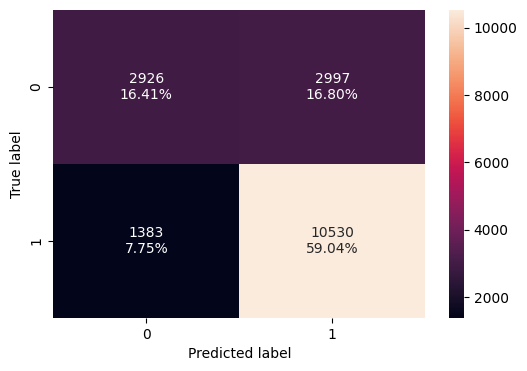

In [ ]:
# Confusion matrix of tuned ab on train:
confusion_matrix_sklearn(abc_tuned, X_train, y_train)

In [ ]:
# Performance metrics of tuned ab on train:
abc_tuned_model_train_perf = model_performance_classification_sklearn(abc_tuned, X_train, y_train)
print("Training performance:\n", abc_tuned_model_train_perf)

Training performance:
    Accuracy    Recall  Precision       F1
0  0.754429  0.883908   0.778443  0.82783


* On train, the tuned AdaBoost model F1 score is .828, with fairly comparable confusion matrix scores as with the pre-tuned AdaBoost model.

##### Check tuned AdaBoost on test

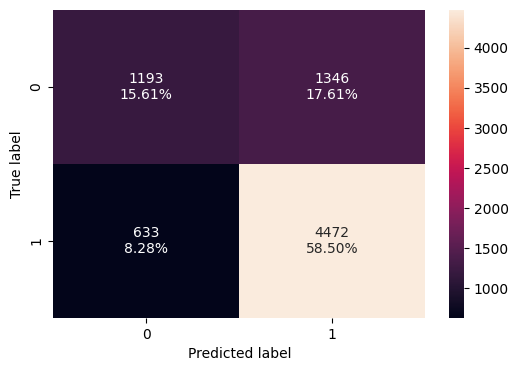

In [ ]:
# Confusion matrix of tuned ab on test:
confusion_matrix_sklearn(abc_tuned, X_test, y_test)

In [ ]:
# Performance metrics of tuned ab on test:
abc_tuned_model_test_perf = model_performance_classification_sklearn(abc_tuned, X_test, y_test)
print("Testing performance:\n", abc_tuned_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.741104  0.876004   0.768649  0.818823


* The F1 score on test barely increased from .816 to .819 on the tuned AdaBoost model over the default AdaBoost model.
* The train and test confusion matrix and F1 scores are comparable with the tuned AdaBoost model.

#### Build Gradient Boosting Classifier (gb)

In [ ]:
# Define Gradient Boosting Classifier with random state = 1:
gb_classifier = GradientBoostingClassifier(random_state=1)

# Fit Gradient Boosting Classifier on the train data:
gb_classifier.fit(X_train, y_train)

GradientBoostingClassifier(random_state=1)

##### Check performance of Gradient Boosting on train

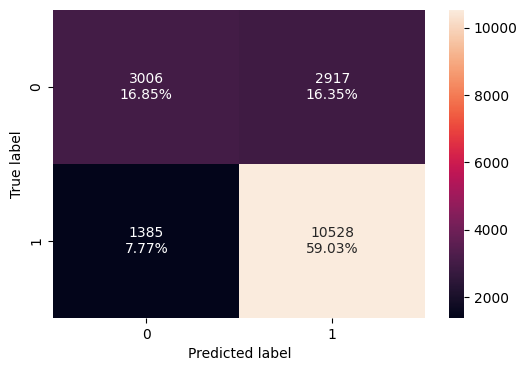

In [ ]:
# Confusion matrix for gb on train:
confusion_matrix_sklearn(gb_classifier, X_train, y_train)

In [ ]:
# Performance metrics for gb on train:
gb_classifier_model_train_perf = model_performance_classification_sklearn(gb_classifier, X_train, y_train)
print("Training performance:\n", gb_classifier_model_train_perf)

Training performance:
    Accuracy   Recall  Precision        F1
0  0.758802  0.88374   0.783042  0.830349


* The default Gradient Boosting model on train is .830, with comparable confusion matrix values as with AdaBoost.

##### Check performance of Gradient Boosting on test

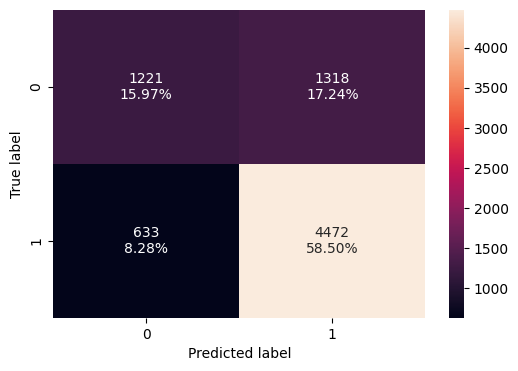

In [ ]:
# Confusion matrix for gb on test:
confusion_matrix_sklearn(gb_classifier, X_test, y_test)

In [ ]:
# Performance metrics for gb on test:
gb_classifier_model_test_perf = model_performance_classification_sklearn(gb_classifier, X_test, y_test)
print("Testing performance:\n", gb_classifier_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.744767  0.876004   0.772366  0.820927


* The default Gradient Boosting model on test is .821, again with nearly the same confusion matrix values as with the tuned AdaBoost model in test.
* Let's see if tuning improves the F1 score.

#### Hyperparameter Tuning - Gradient Boosting

In [ ]:
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search with cv = 5:
grid_obj = GridSearchCV(gbc_tuned, param_grid=parameters, scoring=acc_scorer, cv=5)

## Fit the grid_obj on train data:
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.7, random_state=1,
                           subsample=0.9)

##### Check performance of tuned Gradient Boosting on train

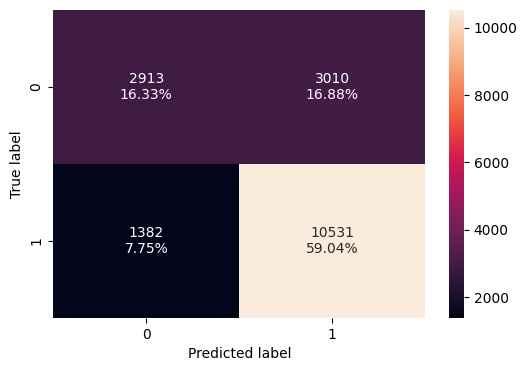

In [ ]:
# Confusion matrix of tuned gb on train:
confusion_matrix_sklearn(gbc_tuned, X_train, y_train)

In [ ]:
# Performance metrics of tuned gb on train:
gbc_tuned_model_train_perf = model_performance_classification_sklearn(gbc_tuned, X_train, y_train)
print("Training performance:\n", gbc_tuned_model_train_perf)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.753756  0.883992   0.777712  0.827453


* On train, the tuned Gradient Boosting model F1 score is still dipped slightly from .830 to .827, with comparable confusion matrix values as pre-tuning.

##### Check performance of tuned Gradient Boosting on test

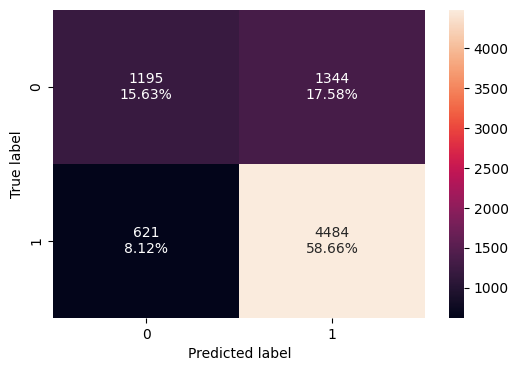

In [ ]:
# Confusion matrix of tuned gb on test:
confusion_matrix_sklearn(gbc_tuned, X_test, y_test)

In [ ]:
# Performance metrics of tuned gb on test:
gbc_tuned_model_test_perf = model_performance_classification_sklearn(gbc_tuned, X_test, y_test)
print("Testing performance:\n", gbc_tuned_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.742936  0.878355   0.769389  0.820269


* In test, the tuned Gradient Boosting model F1 score is .820 (from .821) with comparable confusion matrix values to the default model.
* The confusion matrix and performance scores are more comparable between train and test with the tuned Gradient Boosting model (over the default model).

#### XGBoost Classifier

In [ ]:
# Define XGBoost Classifier with random state = 1 and eval_metric="logloss":
xgb_classifier = XGBClassifier(random_state=1, eval_metric="logloss")

# Fit XGBoost Classifier on the train data:
xgb_classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

##### Check XGBoost performance on train

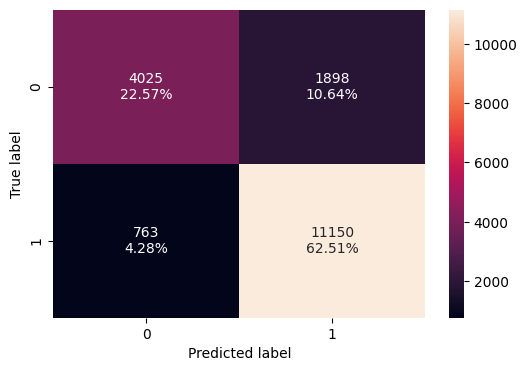

In [ ]:
# Confusion matrix for xg on train:
confusion_matrix_sklearn(xgb_classifier, X_train, y_train)

In [ ]:
# Performance metrics for xg on train:
xgb_classifier_model_train_perf = model_performance_classification_sklearn(xgb_classifier, X_train, y_train)
print("Training performance:\n", xgb_classifier_model_train_perf)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.850807  0.935952   0.854537  0.893394


* The default XGBoost model yields a F1 score of .893 in train.

##### Check XGBoost performance on test

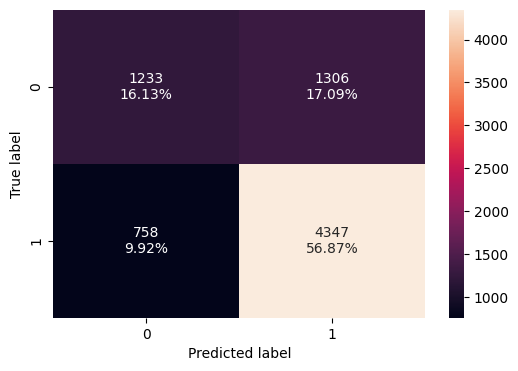

In [ ]:
# Confusion matrix of xg on test:
confusion_matrix_sklearn(xgb_classifier, X_test, y_test)

In [ ]:
# Performance metrics for xg on test:
xgb_classifier_model_test_perf = model_performance_classification_sklearn(xgb_classifier, X_test, y_test)
print("Testing performance:\n", xgb_classifier_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.729984  0.851518   0.768972  0.808143


* The default XGBoost model yields an F1 score of .808 in test.
* The difference in F1 values between train and test is large compared to other models.

#### Hyperparameter Tuning - XGBoost Classifier

In [ ]:
# Choose the type of classifier.
xgb_tuned = XGBClassifier(random_state=1, eval_metric="logloss")

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "scale_pos_weight": [1,2,5],
    "subsample": [0.7,0.9],
    "learning_rate": [0.01,0.1,0.05],
    "gamma": [1,3]
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search with cv = 5:
grid_obj = GridSearchCV(xgb_tuned, param_grid=parameters, scoring=acc_scorer, cv=5)

# Fit the grid_obj on train data:
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

##### Check performance of tuned XGBoost on train

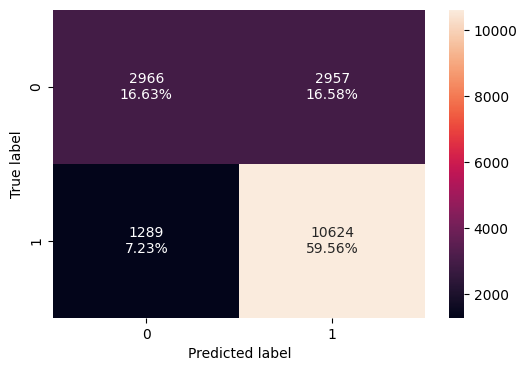

In [ ]:
# Confusion matrix of tuned xg on train:
confusion_matrix_sklearn(xgb_tuned, X_train, y_train)

In [ ]:
# Performance metrics of tuned xg on train:
xgb_tuned_model_train_perf = model_performance_classification_sklearn(xgb_tuned, X_train, y_train)
print("Training performance:\n", xgb_tuned_model_train_perf)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.761942  0.891799   0.782269  0.833451


* The tuned XGBoost model on train decreased from .893 to .833.

##### Check performance of tuned XGBoost on test

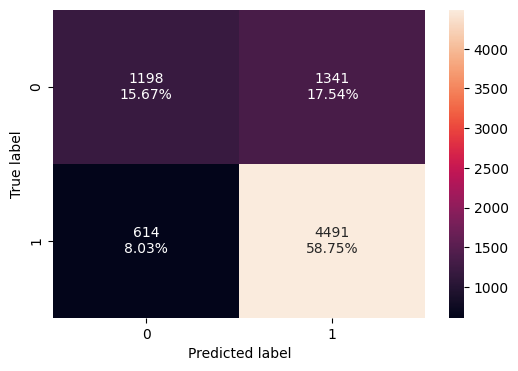

In [ ]:
# Confusion matrix of tuned xg on test:
confusion_matrix_sklearn(xgb_tuned, X_test, y_test)

In [ ]:
# Performance metrics of tuned xg on test:
xgb_tuned_model_test_perf = model_performance_classification_sklearn(xgb_tuned, X_test, y_test)
print("Testing performance:\n", xgb_tuned_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.744244  0.879726   0.770062  0.821249


* The F1 score on the tuned XGBoost model on test increased from .808 to .821.
* The F1 scores between train and test on the tuned XGBoost model are a lot closer than with the default XGBoost model.



## Stacking Classifier
Will use the best of each model type with an F1 score over .80

In [ ]:
# Use the best of each classifier with an F1 score over .8:
estimators = [
    ("Bagging Classifier", bagging_estimator_tuned),
    ("Random Forest", rf_tuned),
    ("AdaBoost", abc_tuned),
    ("Gradient Boosting", gbc_tuned),
    ("XGBoost", xgb_tuned)
]

final_estimator = xgb_tuned
# Define Stacking Classifier:
stacking_classifier = StackingClassifier(
    estimators=estimators, final_estimator=final_estimator
)

# Fit Stacking Classifier on the train data:
stacking_classifier.fit(X_train, y_train)

StackingClassifier(estimators=[('Bagging Classifier',
                                BaggingClassifier(max_features=0.7,
                                                  max_samples=0.8,
                                                  n_estimators=70,
                                                  random_state=1)),
                               ('Random Forest',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_samples=0.4,
                                                       n_estimators=110,
                                                       oob_score=True,
                                                       random_state=1)),
                               ('AdaBoost',
                                AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                                                    random_sta...
                                                 feature_types=None, gamma=3,
                                                 grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.05,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=50, n_jobs=None,
                                                 num_parallel_tree=None,
                                                 random_state=1, ...))

### Check Stacking performance on train

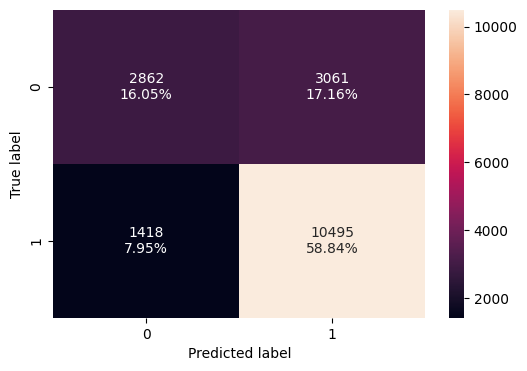

In [ ]:
# Confusion matrix of stacking on train:
confusion_matrix_sklearn(stacking_classifier, X_train, y_train)

In [ ]:
# Performance metrics of stacking on train:
stacking_classifier_model_train_perf = model_performance_classification_sklearn(stacking_classifier, X_train, y_train)
print("Training performance:\n", stacking_classifier_model_train_perf)

Training performance:
    Accuracy   Recall  Precision        F1
0  0.748879  0.88097   0.774196  0.824139


* Using the best of each classifier with test F1 score over .8:
  * Bagging
  * Random Forest
  * AdaBoost
  * Gradient Boosting
  * XGBoost
  
  The stacking model F1 score in train is .824.

### Check Stacking performance on test

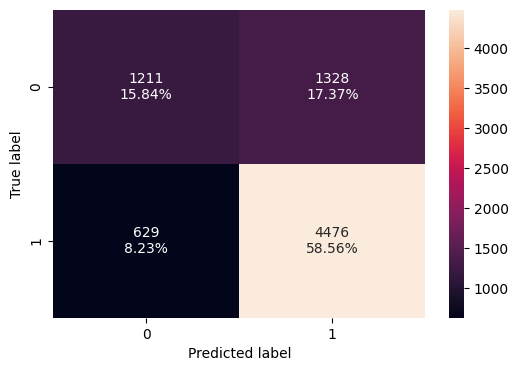

In [ ]:
# Confusion matrix of stacking on test:
confusion_matrix_sklearn(stacking_classifier, X_test, y_test)

In [ ]:
# Performance metrics of stacking on test:
stacking_classifier_model_test_perf = model_performance_classification_sklearn(stacking_classifier, X_test, y_test)
print("Testing performance:\n", stacking_classifier_model_test_perf)

Testing performance:
    Accuracy    Recall  Precision        F1
0  0.743982  0.876787   0.771192  0.820607


* The stacking model F1 score in test is .821.
* The confusion matrix values are very comparable between train and test for the stacking model.

## Model Performance Comparison and Final Model Selection

### Model comparison for train

In [ ]:
# train performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train.T,
        dtree_estimator_model_train_perf.T,
        bagging_classifier_model_train_perf.T,
        bagging_estimator_tuned_model_train_perf.T,
        rf_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        ab_classifier_model_train_perf.T,
        abc_tuned_model_train_perf.T,
        gb_classifier_model_train_perf.T,
        gbc_tuned_model_train_perf.T,
        xgb_classifier_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
        stacking_classifier_model_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Bagging Classifier",
    "Tuned Bagging Classifier",
    "Random Forest",
    "Tuned Random Forest",
    "Adaboost Classifier",
    "Tuned Adaboost Classifier",
    "Gradient Boost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Tuned Decision Tree,Bagging Classifier,Tuned Bagging Classifier,Random Forest,Tuned Random Forest,Adaboost Classifier,Tuned Adaboost Classifier,Gradient Boost Classifier,Tuned Gradient Boost Classifier,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,1.0,0.710193,0.985198,0.998710,1.0,0.917975,0.738226,0.754429,0.758802,0.753756,0.850807,0.761942,0.748879
Recall,1.0,0.725762,0.985982,0.999916,1.0,0.975153,0.887182,0.883908,0.883740,0.883992,0.935952,0.891799,0.880970
Precision,1.0,0.819681,0.991810,0.998157,1.0,0.908714,0.760688,0.778443,0.783042,0.777712,0.854537,0.782269,0.774196
F1,1.0,0.769868,0.988887,0.999036,1.0,0.940762,0.819080,0.827830,0.830349,0.827453,0.893394,0.833451,0.824139


### Model comparison for test

In [ ]:
# Test performance comparison:
models_test_comp_df = pd.concat(
    [
        decision_tree_perf_test.T,
        dtree_estimator_model_test_perf.T,
        bagging_classifier_model_test_perf.T,
        bagging_estimator_tuned_model_test_perf.T,
        rf_estimator_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        ab_classifier_model_test_perf.T,
        abc_tuned_model_test_perf.T,
        gb_classifier_model_test_perf.T,
        gbc_tuned_model_test_perf.T,
        xgb_classifier_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
        stacking_classifier_model_test_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Bagging Classifier",
    "Tuned Bagging Classifier",
    "Random Forest",
    "Tuned Random Forest",
    "Adaboost Classifier",
    "Tuned Adaboost Classifier",
    "Gradient Boost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier",
]
print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Tuned Decision Tree,Bagging Classifier,Tuned Bagging Classifier,Random Forest,Tuned Random Forest,Adaboost Classifier,Tuned Adaboost Classifier,Gradient Boost Classifier,Tuned Gradient Boost Classifier,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,0.654893,0.707483,0.691523,0.725929,0.727368,0.731293,0.734301,0.741104,0.744767,0.742936,0.729984,0.744244,0.743982
Recall,0.747502,0.726543,0.764153,0.888737,0.847209,0.864643,0.885015,0.876004,0.876004,0.878355,0.851518,0.879726,0.876787
Precision,0.738819,0.815344,0.771711,0.748186,0.768343,0.764064,0.757799,0.768649,0.772366,0.769389,0.768972,0.770062,0.771192
F1,0.743135,0.768386,0.767913,0.812427,0.805851,0.811248,0.816481,0.818823,0.820927,0.820269,0.808143,0.821249,0.820607


### Model Selection:  XGBoost

* The tuned XGBoost Model has the highest F1 score on test -- .821249.
* The performance metrics for this model are comparable between train and test.
* The default (untuned) Gradient Boost classifer has the next highest F1 score at .820927, making this model a close second.



### Important features of the final model (tuned XGBoost)

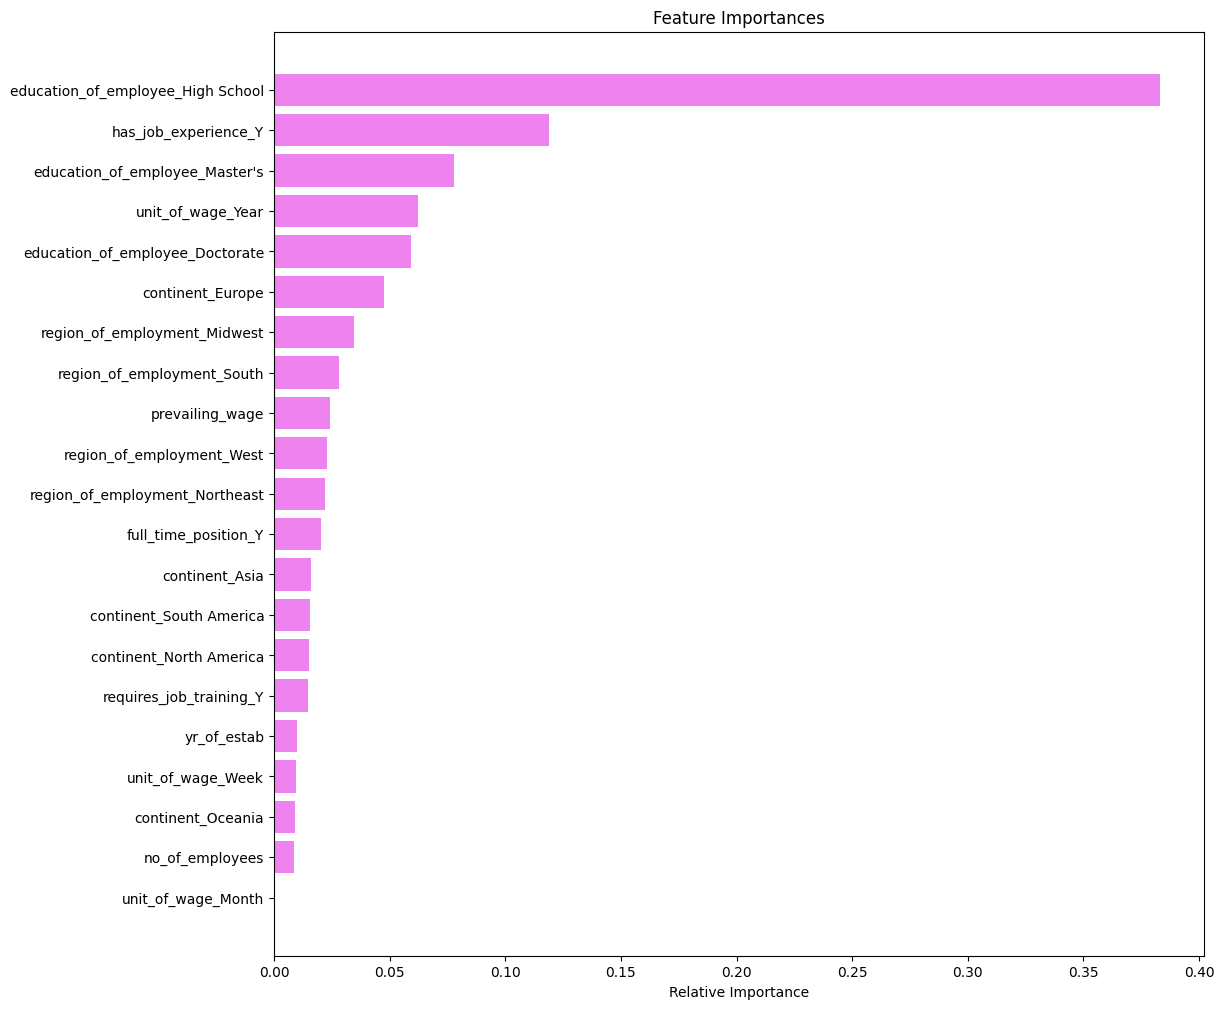

In [ ]:
# Plot the features in order of importance for the tuned XGBoost model:
feature_names = X_train.columns
importances = xgb_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* The single most predictive feature for the model is visa applicants with only a high-school education, with a relative importance between .35 and .40.

* The next four most imporant feature significant for model accuracy are for (in descending order):
  * applicants with prior job experience (~ .13)
  * applicants with master's degrees (~ .08)
  * unit of wage is yearly (~ .07)
  * applicants with doctorate degrees (~ .06)

## Actionable Insights and Recommendations

* Based on this analysis, visas that receive certification status have the following features compared to those that are denied:
  * **Higher education** overall -- the higher the education, the higher the percentage of approvals;  conversely, those with no higher education are the biggest indicator of a denied status:
    * 87% of applicants with a Doctorate's degree are approved.
    * 79% of applicants with a master's degree receive approval.
    * 66% with only a high-school education are denied.
  * **Prior job experience** -- those with job experience are approved 75% of the time as opposed to 56% approvals for those without job experience.
  * **Annual salary workers** -- applicants paid at an annual wage unit are more likely to be full-time employees and are approved 70% of the time.
  * **From Europe** -- 80% of European applicants receive approval.
  * **US Region** -- the highest percentage of certified applicants are for the Midwest region (76%), followed by South (70%).
  * **Prevailing wage** -- The median wage for certified applicants overall is $72,48.

* EasyVisa should prioritze visa applications in order of the highest education with prior job experience for full-time salaried positions, particularly for jobs in the Midwest or South.
* Applicants with only a high-school education should only be considered if they possess a unique or exceptional skillset or experience not already easily available within the US workforce.
* The data provided for prevailing wages may need to be reviewed for accuracy and better categorized by full/part-time, temporary (less than 1 year) or permanent, industry, and general job class in order to make any true assessments about how this may impact approvals.  
  * Using the current data, it appears those with doctorates are approved at a higher rate while generally making significantly less than all other education levels.
  * The current data also does not appear to support protection of local or foreign labor.

